# Projeto de Engenharia de Dados em Cibersegurança

Este notebook consolida as etapas de **Bronze** e **Prata** a partir dos datasets enviados.

## Esse notebook inicial contém:
1. Ingestão Bronze com metadados e persistência em Parquet  
2. Relatório automático de qualidade dos dados da Bronze  
3. Construção da camada Prata com limpezas e padronizações  
4. Checklist anti-leakage e dataset final preparado para ML  
5. Data lineage do pipeline  
6. Visualizações exploratórias  


In [ ]:

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer

plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

PROJECT_ROOT = Path.cwd()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
BRONZE_DIR = PROJECT_ROOT / "data" / "bronze"
SILVER_DIR = PROJECT_ROOT / "data" / "silver"
QUALITY_DIR = BRONZE_DIR / "_quality"
META_DIR = BRONZE_DIR / "_meta"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIG_DIR = REPORTS_DIR / "figures"
DOCS_DIR = PROJECT_ROOT / "docs"

for path in [RAW_DIR, BRONZE_DIR, SILVER_DIR, QUALITY_DIR, META_DIR, REPORTS_DIR, FIG_DIR, DOCS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

**Diretório do projeto:** `c:\Users\cactu\Desktop\projeto_cyberseguranca_v6\projeto_cyberseguranca_v6`

In [2]:

df_inc_raw = pd.read_csv(RAW_DIR / "incidents_master.csv")
df_fin_raw = pd.read_csv(RAW_DIR / "financial_impact.csv")
df_mkt_raw = pd.read_csv(RAW_DIR / "market_impact.csv")

raw_summary = pd.DataFrame([
    {"dataset": "incidents_master", "linhas": len(df_inc_raw), "colunas": df_inc_raw.shape[1]},
    {"dataset": "financial_impact", "linhas": len(df_fin_raw), "colunas": df_fin_raw.shape[1]},
    {"dataset": "market_impact", "linhas": len(df_mkt_raw), "colunas": df_mkt_raw.shape[1]},
])
display(raw_summary)


,dataset,linhas,colunas
0,incidents_master,850,32
1,financial_impact,778,19
2,market_impact,358,31


## 1) Camada Bronze

In [3]:

def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    cols = []
    for c in df.columns:
        c = c.strip().lower()
        c = re.sub(r"[\s\-.]+", "_", c)
        c = re.sub(r"[^a-z0-9_]", "", c)
        c = re.sub(r"_+", "_", c).strip("_")
        cols.append(c)
    out = df.copy()
    out.columns = cols
    return out

def file_sha256(path: Path) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(65536), b""):
            h.update(chunk)
    return h.hexdigest()

def coerce_basic_types(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    bool_candidates = [c for c in out.columns if c.startswith("is_") or c.endswith("_estimated") or c.startswith("earnings_")]
    for c in bool_candidates:
        if c in out.columns:
            out[c] = out[c].astype("boolean")
    return out

def ingest_bronze(df_raw: pd.DataFrame, source_name: str):
    source_path = RAW_DIR / source_name
    dataset_name = source_path.stem
    ingestion_ts = datetime.now(timezone.utc).isoformat()

    df = normalize_columns(df_raw)
    df = coerce_basic_types(df)

    df["_ingestion_timestamp"] = ingestion_ts
    df["_source_file"] = source_path.name
    df["_file_hash_sha256"] = file_sha256(source_path)
    df["_file_size_bytes"] = source_path.stat().st_size

    target_dir = BRONZE_DIR / dataset_name
    target_dir.mkdir(parents=True, exist_ok=True)
    parquet_path = target_dir / f"{dataset_name}.parquet"
    df.to_parquet(parquet_path, index=False)

    meta = {
        "dataset": dataset_name,
        "source_file": source_path.name,
        "source_path": str(source_path.relative_to(PROJECT_ROOT)),
        "parquet_path": str(parquet_path.relative_to(PROJECT_ROOT)),
        "num_rows": int(len(df)),
        "num_columns": int(df.shape[1]),
        "file_hash_sha256": file_sha256(source_path),
        "file_size_bytes": int(source_path.stat().st_size),
        "ingestion_ts_utc": ingestion_ts,
        "columns": df.columns.tolist(),
        "layer": "bronze",
    }
    with open(META_DIR / f"{dataset_name}_meta.json", "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2, ensure_ascii=False)
    return df, meta


In [4]:
df_bronze_inc, meta_inc = ingest_bronze(df_inc_raw, "incidents_master.csv")
df_bronze_fin, meta_fin = ingest_bronze(df_fin_raw, "financial_impact.csv")
df_bronze_mkt, meta_mkt = ingest_bronze(df_mkt_raw, "market_impact.csv")

bronze_summary = pd.DataFrame([meta_inc, meta_fin, meta_mkt])[
    ["dataset", "source_file", "num_rows", "num_columns", "file_size_bytes", "ingestion_ts_utc"]
]
display(bronze_summary)

with open(META_DIR / "bronze_ingestion_summary.json", "w", encoding="utf-8") as f:
    json.dump([meta_inc, meta_fin, meta_mkt], f, indent=2, ensure_ascii=False)


,dataset,source_file,num_rows,num_columns,file_size_bytes,ingestion_ts_utc
0,incidents_master,incidents_master.csv,850,36,438941,2026-05-28T01:21:10.299622+00:00
1,financial_impact,financial_impact.csv,778,23,170578,2026-05-28T01:21:10.541765+00:00
2,market_impact,market_impact.csv,358,35,109318,2026-05-28T01:21:10.550351+00:00


## 2) Qualidade de Dados da Bronze

In [5]:

DATE_COLS = {
    "incidents_master": ["incident_date", "discovery_date", "disclosure_date", "created_at", "updated_at"],
    "financial_impact": ["created_at", "updated_at"],
    "market_impact": ["created_at", "updated_at"],
}

ALLOWED_ATTACK_VECTORS = {"ransomware", "phishing", "data_breach", "apt", "malware", "ddos", "supply_chain", "trojan", "backdoor"}
ALLOWED_ATTRIBUTION = {"confirmed", "probable", "suspected", "unknown"}

bronze_tables = {
    "incidents_master": df_bronze_inc.copy(),
    "financial_impact": df_bronze_fin.copy(),
    "market_impact": df_bronze_mkt.copy(),
}

def parse_dates(df: pd.DataFrame, cols):
    return {c: pd.to_datetime(df[c], errors="coerce", utc=True) for c in cols if c in df.columns}

def add_rule(results, dataset, rule_id, severity, status, affected_records, criterion, description):
    results.append({
        "dataset": dataset,
        "rule_id": rule_id,
        "severity": severity,
        "status": status,
        "affected_records": int(affected_records),
        "criterion": criterion,
        "description": description,
    })

validation_results = []
missing_rows = []

for name, df in bronze_tables.items():
    date_map = parse_dates(df, DATE_COLS[name])

    miss = (
        df.isna().sum().rename("nulls").to_frame()
        .assign(null_pct=lambda x: (x["nulls"] / len(df) * 100).round(2))
        .reset_index().rename(columns={"index": "column"})
        .query("nulls > 0")
        .sort_values(["null_pct", "nulls"], ascending=False)
    )
    miss["dataset"] = name
    missing_rows.append(miss)

    add_rule(validation_results, name, "pk_not_null", "critical",
             "PASS" if df["incident_id"].notna().all() else "FAIL",
             df["incident_id"].isna().sum(),
             "incident_id sem valores nulos",
             "A chave de negócio deve estar preenchida em 100% das linhas.")
    add_rule(validation_results, name, "pk_unique", "critical",
             "PASS" if not df["incident_id"].duplicated().any() else "FAIL",
             df["incident_id"].duplicated().sum(),
             "incident_id único",
             "A chave de negócio não pode se repetir dentro do dataset.")
    add_rule(validation_results, name, "full_row_duplicates", "warning",
             "PASS" if not df.duplicated().any() else "WARN",
             df.duplicated().sum(),
             "0 linhas duplicadas completas",
             "Verifica duplicação integral de linhas.")

    for col, parsed in date_map.items():
        invalid = int(df[col].notna().sum() - parsed.notna().sum())
        add_rule(validation_results, name, f"date_parse_{col}", "critical",
                 "PASS" if invalid == 0 else "FAIL",
                 invalid,
                 f"{col} totalmente parseável",
                 f"Todos os valores de {col} devem seguir padrão de data válido.")

    high_missing = int((df.isna().mean() > 0.50).sum())
    add_rule(validation_results, name, "high_missing_columns", "warning",
             "PASS" if high_missing == 0 else "WARN",
             high_missing,
             "até 50% de nulos por coluna",
             "Sinaliza colunas com alta incompletude na Bronze.")

inc = bronze_tables["incidents_master"].copy()
inc_dates = parse_dates(inc, DATE_COLS["incidents_master"])
invalid_country = (~inc["country_hq"].fillna("").astype(str).str.fullmatch(r"[A-Z]{2}")).sum()
invalid_attack = (~inc["attack_vector_primary"].isin(ALLOWED_ATTACK_VECTORS)).sum()
invalid_attr = (~inc["attribution_confidence"].dropna().isin(ALLOWED_ATTRIBUTION)).sum()
discovery_before = ((inc_dates["discovery_date"] < inc_dates["incident_date"]) & inc_dates["discovery_date"].notna() & inc_dates["incident_date"].notna()).sum()
disclosure_before = ((inc_dates["disclosure_date"] < inc_dates["discovery_date"]) & inc_dates["disclosure_date"].notna() & inc_dates["discovery_date"].notna()).sum()
quality_outside = (((inc["quality_score"] < 0) | (inc["quality_score"] > 100))).sum()
negatives_inc = int(sum((inc[c] < 0).sum() for c in ["company_revenue_usd", "employee_count", "data_compromised_records", "downtime_hours"]))

add_rule(validation_results, "incidents_master", "country_hq_iso2", "critical",
         "PASS" if invalid_country == 0 else "FAIL", invalid_country,
         "country_hq no formato [A-Z]{2}",
         "País da sede deve seguir padrão ISO-2 em letras maiúsculas.")
add_rule(validation_results, "incidents_master", "attack_vector_domain", "critical",
         "PASS" if invalid_attack == 0 else "FAIL", invalid_attack,
         "attack_vector_primary em domínio conhecido",
         "Vetor primário deve pertencer à lista esperada de categorias.")
add_rule(validation_results, "incidents_master", "attribution_confidence_domain", "warning",
         "PASS" if invalid_attr == 0 else "WARN", invalid_attr,
         "attribution_confidence em domínio conhecido",
         "Confiança de atribuição deve pertencer à lista esperada.")
add_rule(validation_results, "incidents_master", "discovery_after_incident", "critical",
         "PASS" if discovery_before == 0 else "FAIL", discovery_before,
         "discovery_date >= incident_date",
         "A descoberta não pode acontecer antes do incidente.")
add_rule(validation_results, "incidents_master", "disclosure_after_discovery", "critical",
         "PASS" if disclosure_before == 0 else "FAIL", disclosure_before,
         "disclosure_date >= discovery_date",
         "A divulgação não pode acontecer antes da descoberta.")
add_rule(validation_results, "incidents_master", "quality_score_range", "critical",
         "PASS" if quality_outside == 0 else "FAIL", quality_outside,
         "0 <= quality_score <= 100",
         "Pontuação de qualidade deve ficar no intervalo fechado [0,100].")
add_rule(validation_results, "incidents_master", "non_negative_numeric", "critical",
         "PASS" if negatives_inc == 0 else "FAIL", negatives_inc,
         "campos numéricos não negativos",
         "Receita, funcionários, downtime e registros comprometidos não podem ser negativos.")

fin = bronze_tables["financial_impact"].copy()
negatives_fin = int(sum((fin[c] < 0).sum() for c in ["direct_loss_usd", "ransom_demanded_usd", "ransom_paid_usd", "recovery_cost_usd", "legal_fees_usd", "regulatory_fine_usd", "insurance_payout_usd", "total_loss_usd", "total_loss_lower_bound", "total_loss_upper_bound", "inflation_adjusted_usd"]))
insurance_gt_total = ((fin["insurance_payout_usd"] > fin["total_loss_usd"]) & fin["insurance_payout_usd"].notna() & fin["total_loss_usd"].notna()).sum()
bounds_invalid = (((fin["total_loss_usd"] < fin["total_loss_lower_bound"]) | (fin["total_loss_usd"] > fin["total_loss_upper_bound"])) & fin["total_loss_usd"].notna() & fin["total_loss_lower_bound"].notna() & fin["total_loss_upper_bound"].notna()).sum()
fk_fin_missing = (~fin["incident_id"].isin(inc["incident_id"])).sum()

add_rule(validation_results, "financial_impact", "non_negative_numeric", "critical",
         "PASS" if negatives_fin == 0 else "FAIL", negatives_fin,
         "campos financeiros não negativos",
         "Valores monetários não podem ser negativos.")
add_rule(validation_results, "financial_impact", "insurance_lte_total", "critical",
         "PASS" if insurance_gt_total == 0 else "FAIL", insurance_gt_total,
         "insurance_payout_usd <= total_loss_usd",
         "Reembolso do seguro não deve superar a perda total declarada.")
add_rule(validation_results, "financial_impact", "total_inside_bounds", "critical",
         "PASS" if bounds_invalid == 0 else "FAIL", bounds_invalid,
         "total_loss_usd entre lower_bound e upper_bound",
         "Perda total deve cair dentro do intervalo declarado.")
add_rule(validation_results, "financial_impact", "fk_incident_exists", "critical",
         "PASS" if fk_fin_missing == 0 else "FAIL", fk_fin_missing,
         "incident_id contido em incidents_master",
         "Toda linha de impacto financeiro deve referenciar um incidente existente.")

mkt = bronze_tables["market_impact"].copy()
negatives_mkt = int(sum((mkt[c] < 0).sum() for c in ["price_7d_before", "price_disclosure_day", "price_1d_after", "price_7d_after", "price_30d_after", "market_cap_at_disclosure", "pre_incident_volatility_30d", "post_incident_volatility_30d"]))
pvals_invalid = int((((mkt["p_value_1d"] < 0) | (mkt["p_value_1d"] > 1)).sum()) + (((mkt["p_value_30d"] < 0) | (mkt["p_value_30d"] > 1)).sum()))
fk_mkt_missing = (~mkt["incident_id"].isin(inc["incident_id"])).sum()
volume_ratio_negative = (mkt["volume_ratio_disclosure"] < 0).sum()

add_rule(validation_results, "market_impact", "non_negative_prices", "critical",
         "PASS" if negatives_mkt == 0 else "FAIL", negatives_mkt,
         "preços, market cap e volatilidades não negativos",
         "Campos de mercado básicos não podem ser negativos.")
add_rule(validation_results, "market_impact", "p_values_between_0_1", "critical",
         "PASS" if pvals_invalid == 0 else "FAIL", pvals_invalid,
         "0 <= p_value <= 1",
         "P-values precisam estar dentro do intervalo [0,1].")
add_rule(validation_results, "market_impact", "volume_ratio_non_negative", "critical",
         "PASS" if volume_ratio_negative == 0 else "FAIL", volume_ratio_negative,
         "volume_ratio_disclosure >= 0",
         "Razão de volume no disclosure deve ser não negativa.")
add_rule(validation_results, "market_impact", "fk_incident_exists", "critical",
         "PASS" if fk_mkt_missing == 0 else "FAIL", fk_mkt_missing,
         "incident_id contido em incidents_master",
         "Toda linha de impacto de mercado deve referenciar um incidente existente.")

validation_df = pd.DataFrame(validation_results).sort_values(["dataset", "severity", "rule_id"]).reset_index(drop=True)
missingness_df = pd.concat(missing_rows, ignore_index=True)

validation_df.to_csv(QUALITY_DIR / "bronze_quality_rules.csv", index=False)
missingness_df.to_csv(QUALITY_DIR / "bronze_missingness.csv", index=False)

display(validation_df.head(20))
display(missingness_df.groupby("dataset").head(8))
status_counts = validation_df["status"].value_counts().rename_axis("status").reset_index(name="qtd")
display(status_counts)


,dataset,rule_id,severity,status,affected_records,criterion,description
0,financial_impact,date_parse_created_at,critical,PASS,0,created_at totalmente parseável,Todos os valores de created_at devem seguir pa...
1,financial_impact,date_parse_updated_at,critical,PASS,0,updated_at totalmente parseável,Todos os valores de updated_at devem seguir pa...
2,financial_impact,fk_incident_exists,critical,PASS,0,incident_id contido em incidents_master,Toda linha de impacto financeiro deve referenc...
3,financial_impact,insurance_lte_total,critical,PASS,0,insurance_payout_usd <= total_loss_usd,Reembolso do seguro não deve superar a perda t...
4,financial_impact,non_negative_numeric,critical,PASS,0,campos financeiros não negativos,Valores monetários não podem ser negativos.
5,financial_impact,pk_not_null,critical,PASS,0,incident_id sem valores nulos,A chave de negócio deve estar preenchida em 10...
6,financial_impact,pk_unique,critical,PASS,0,incident_id único,A chave de negócio não pode se repetir dentro ...
7,financial_impact,total_inside_bounds,critical,PASS,0,total_loss_usd entre lower_bound e upper_bound,Perda total deve cair dentro do intervalo decl...
8,financial_impact,full_row_duplicates,warning,PASS,0,0 linhas duplicadas completas,Verifica duplicação integral de linhas.
9,financial_impact,high_missing_columns,warning,WARN,5,até 50% de nulos por coluna,Sinaliza colunas com alta incompletude na Bronze.


,column,nulls,null_pct,dataset
0,review_flag,780,91.76,incidents_master
1,industry_secondary,697,82.00,incidents_master
2,attack_vector_secondary,639,75.18,incidents_master
3,notes,636,74.82,incidents_master
4,data_source_secondary,464,54.59,incidents_master
5,stock_ticker,438,51.53,incidents_master
6,downtime_hours,430,50.59,incidents_master
7,attributed_group,368,43.29,incidents_master
12,ransom_paid_usd,692,88.95,financial_impact
13,ransom_source,692,88.95,financial_impact


,status,qtd
0,PASS,33
1,WARN,3


In [6]:

top_missing = []
for dataset, grp in missingness_df.groupby("dataset"):
    top = grp.sort_values(["null_pct", "nulls"], ascending=False).head(8)
    lines = "\n".join(
        [f"| {row.column} | {int(row.nulls)} | {row.null_pct:.2f}% |" for _, row in top.iterrows()]
    ) or "| - | 0 | 0.00% |"
    top_missing.append(
        f"### {dataset}\n\n| coluna | nulos | % nulos |\n|---|---:|---:|\n{lines}\n"
    )

fails = validation_df.query("status == 'FAIL'")
warns = validation_df.query("status == 'WARN'")
summary_lines = [
    "# Relatório de Qualidade de Dados — Bronze",
    "",
    "## Visão geral",
    f"- Datasets avaliados: **3**",
    f"- Regras executadas: **{len(validation_df)}**",
    f"- PASS: **{(validation_df['status'] == 'PASS').sum()}**",
    f"- WARN: **{(validation_df['status'] == 'WARN').sum()}**",
    f"- FAIL: **{(validation_df['status'] == 'FAIL').sum()}**",
    "",
    "## Principais achados",
    "- Não foram encontrados problemas críticos de unicidade, integridade referencial, parse de datas ou valores negativos.",
    "- O principal ponto de atenção da Bronze é a **incompletude em colunas opcionais**, especialmente campos secundários, notas e indicadores retroativos.",
    "- A tabela `market_impact` possui menor cobertura por natureza do negócio: ela existe apenas para empresas com contexto de mercado disponível.",
    "",
    "## Regras com WARN/FAIL",
]
if len(fails) == 0 and len(warns) == 0:
    summary_lines.append("- Nenhuma regra retornou WARN/FAIL.")
else:
    summary_lines.extend([
        "",
        "| dataset | regra | status | registros afetados | critério |",
        "|---|---|---|---:|---|",
    ])
    for _, row in pd.concat([fails, warns]).iterrows():
        summary_lines.append(f"| {row.dataset} | {row.rule_id} | {row.status} | {int(row.affected_records)} | {row.criterion} |")

summary_lines.extend([
    "",
    "## Top colunas com nulos",
    "",
    *top_missing,
    "",
    "## Conclusão",
    "A Bronze foi **aprovada com observações**: as regras críticas passaram, mas há colunas com alta taxa de nulos que exigem tratamento na camada Prata.",
])

quality_md = "\n".join(summary_lines)
(QUALITY_DIR / "bronze_quality_report.md").write_text(quality_md, encoding="utf-8")
display(Markdown(quality_md[:2500] + ("\n\n..." if len(quality_md) > 2500 else "")))


# Relatório de Qualidade de Dados — Bronze

## Visão geral
- Datasets avaliados: **3**
- Regras executadas: **36**
- PASS: **33**
- WARN: **3**
- FAIL: **0**

## Principais achados
- Não foram encontrados problemas críticos de unicidade, integridade referencial, parse de datas ou valores negativos.
- O principal ponto de atenção da Bronze é a **incompletude em colunas opcionais**, especialmente campos secundários, notas e indicadores retroativos.
- A tabela `market_impact` possui menor cobertura por natureza do negócio: ela existe apenas para empresas com contexto de mercado disponível.

## Regras com WARN/FAIL

| dataset | regra | status | registros afetados | critério |
|---|---|---|---:|---|
| financial_impact | high_missing_columns | WARN | 5 | até 50% de nulos por coluna |
| incidents_master | high_missing_columns | WARN | 7 | até 50% de nulos por coluna |
| market_impact | high_missing_columns | WARN | 1 | até 50% de nulos por coluna |

## Top colunas com nulos

### financial_impact

| coluna | nulos | % nulos |
|---|---:|---:|
| ransom_paid_usd | 692 | 88.95% |
| ransom_source | 692 | 88.95% |
| regulatory_fine_usd | 646 | 83.03% |
| ransom_demanded_usd | 572 | 73.52% |
| notes | 530 | 68.12% |
| insurance_payout_usd | 343 | 44.09% |

### incidents_master

| coluna | nulos | % nulos |
|---|---:|---:|
| review_flag | 780 | 91.76% |
| industry_secondary | 697 | 82.00% |
| attack_vector_secondary | 639 | 75.18% |
| notes | 636 | 74.82% |
| data_source_secondary | 464 | 54.59% |
| stock_ticker | 438 | 51.53% |
| downtime_hours | 430 | 50.59% |
| attributed_group | 368 | 43.29% |

### market_impact

| coluna | nulos | % nulos |
|---|---:|---:|
| notes | 266 | 74.30% |
| days_to_price_recovery | 36 | 10.06% |


## Conclusão
A Bronze foi **aprovada com observações**: as regras críticas passaram, mas há colunas com alta taxa de nulos que exigem tratamento na camada Prata.

## 3) Camada Prata

In [7]:

df_inc = pd.read_parquet(BRONZE_DIR / "incidents_master" / "incidents_master.parquet")
df_fin = pd.read_parquet(BRONZE_DIR / "financial_impact" / "financial_impact.parquet")
df_mkt = pd.read_parquet(BRONZE_DIR / "market_impact" / "market_impact.parquet")

meta_cols = ["_ingestion_timestamp", "_source_file", "_file_hash_sha256", "_file_size_bytes"]
df_inc = df_inc.drop(columns=[c for c in meta_cols if c in df_inc.columns])
df_fin = df_fin.drop(columns=[c for c in meta_cols if c in df_fin.columns])
df_mkt = df_mkt.drop(columns=[c for c in meta_cols if c in df_mkt.columns])

df_silver_inc = df_inc.copy()
df_silver_fin = df_fin.copy()
df_silver_mkt = df_mkt.copy()

for col in ["incident_date", "discovery_date", "disclosure_date", "created_at", "updated_at"]:
    if col in df_silver_inc.columns:
        df_silver_inc[col] = pd.to_datetime(df_silver_inc[col], errors="coerce", utc=True)
for col in ["created_at", "updated_at"]:
    if col in df_silver_fin.columns:
        df_silver_fin[col] = pd.to_datetime(df_silver_fin[col], errors="coerce", utc=True)
    if col in df_silver_mkt.columns:
        df_silver_mkt[col] = pd.to_datetime(df_silver_mkt[col], errors="coerce", utc=True)

for col in ["attack_vector_primary", "attack_vector_secondary", "attribution_confidence", "data_type", "data_source_type", "quality_grade"]:
    if col in df_silver_inc.columns:
        df_silver_inc[col] = df_silver_inc[col].astype("string").str.strip().str.lower()
for col in ["direct_loss_method", "total_loss_method"]:
    if col in df_silver_fin.columns:
        df_silver_fin[col] = df_silver_fin[col].astype("string").str.strip().str.lower()

fill_text_inc = {
    "industry_secondary": "nao_informado",
    "attack_vector_secondary": "nao_informado",
    "attributed_group": "nao_informado",
    "attribution_confidence": "unknown",
    "attack_chain": "nao_informado",
    "data_type": "nao_informado",
    "notes": "nao_informado",
    "review_flag": "nao_informado",
    "stock_ticker": "nao_listada",
    "data_source_secondary": "nao_informado",
}
for col, value in fill_text_inc.items():
    if col in df_silver_inc.columns:
        df_silver_inc[col] = df_silver_inc[col].fillna(value)

for col in ["data_compromised_records", "downtime_hours"]:
    if col in df_silver_inc.columns:
        df_silver_inc[col] = df_silver_inc[col].fillna(df_silver_inc[col].median())

for col in ["ransom_demanded_usd", "ransom_paid_usd", "regulatory_fine_usd", "insurance_payout_usd"]:
    if col in df_silver_fin.columns:
        df_silver_fin[col] = df_silver_fin[col].fillna(0)
if "ransom_source" in df_silver_fin.columns:
    df_silver_fin["ransom_source"] = df_silver_fin["ransom_source"].fillna("nao_informado")
if "notes" in df_silver_fin.columns:
    df_silver_fin["notes"] = df_silver_fin["notes"].fillna("nao_informado")

if "days_to_price_recovery" in df_silver_mkt.columns:
    df_silver_mkt["days_to_price_recovery"] = df_silver_mkt["days_to_price_recovery"].fillna(-1)
if "notes" in df_silver_mkt.columns:
    df_silver_mkt["notes"] = df_silver_mkt["notes"].fillna("nao_informado")

df_silver_inc = df_silver_inc.drop_duplicates(subset=["incident_id"]).copy()
df_silver_fin = df_silver_fin.drop_duplicates(subset=["incident_id"]).copy()
df_silver_mkt = df_silver_mkt.drop_duplicates(subset=["incident_id"]).copy()

df_silver_inc["ano_incidente"] = df_silver_inc["incident_date"].dt.year
df_silver_inc["mes_incidente"] = df_silver_inc["incident_date"].dt.month
df_silver_inc["trimestre_incidente"] = df_silver_inc["incident_date"].dt.quarter
df_silver_inc["dias_ate_descoberta"] = (df_silver_inc["discovery_date"] - df_silver_inc["incident_date"]).dt.days
df_silver_inc["dias_ate_divulgacao"] = (df_silver_inc["disclosure_date"] - df_silver_inc["discovery_date"]).dt.days
df_silver_inc["flag_ransomware"] = (df_silver_inc["attack_vector_primary"] == "ransomware").astype(int)

def porte_empresa(n):
    if pd.isna(n):
        return "nao_informado"
    if n < 100:
        return "micro"
    if n < 500:
        return "pequena"
    if n < 5000:
        return "media"
    return "grande"

df_silver_inc["porte_empresa"] = df_silver_inc["employee_count"].apply(porte_empresa)
df_silver_inc["flag_atribuicao_conhecida"] = df_silver_inc["attribution_confidence"].isin(["confirmed", "probable"]).astype(int)

df_silver_fin["proporcao_seguro"] = (
    df_silver_fin["insurance_payout_usd"] / df_silver_fin["total_loss_usd"].replace(0, np.nan)
).fillna(0).round(4)
df_silver_fin["flag_resgate_pago"] = (df_silver_fin["ransom_paid_usd"] > 0).astype(int)

df_silver_mkt["flag_queda_acentuada"] = (df_silver_mkt["abnormal_return_1d"] < -0.05).astype(int)
df_silver_mkt["aumento_volatilidade"] = (
    df_silver_mkt["post_incident_volatility_30d"] - df_silver_mkt["pre_incident_volatility_30d"]
).round(4)

mediana_downtime = df_silver_inc["downtime_hours"].median()
mediana_registros = df_silver_inc["data_compromised_records"].median()
df_silver_inc["flag_alto_impacto"] = (
    (df_silver_inc["downtime_hours"] >= mediana_downtime) &
    (df_silver_inc["data_compromised_records"] >= mediana_registros)
).astype(int)

silver_summary = pd.DataFrame([
    {"dataset": "incidents_master", "linhas": len(df_silver_inc), "colunas": df_silver_inc.shape[1]},
    {"dataset": "financial_impact", "linhas": len(df_silver_fin), "colunas": df_silver_fin.shape[1]},
    {"dataset": "market_impact", "linhas": len(df_silver_mkt), "colunas": df_silver_mkt.shape[1]},
])
display(silver_summary)


,dataset,linhas,colunas
0,incidents_master,850,41
1,financial_impact,778,21
2,market_impact,358,33


## 4) Anti-leakage e dataset final para ML

In [8]:

leakage_rows = [
    ("incidents_master", "quality_score", "retroativo", "score calculado após curadoria do caso", "remover"),
    ("incidents_master", "quality_grade", "retroativo", "faixa derivada após avaliação do caso", "remover"),
    ("incidents_master", "review_flag", "retroativo", "sinal de revisão humana posterior", "remover"),
    ("incidents_master", "discovery_date", "futuro", "informação conhecida após o incidente", "remover"),
    ("incidents_master", "disclosure_date", "futuro", "informação conhecida após o incidente", "remover"),
    ("incidents_master", "updated_at", "técnico/retroativo", "carimbo de atualização posterior", "remover"),
    ("incidents_master", "created_at", "técnico", "carimbo de carga/cadastro, sem valor preditivo", "remover"),
    ("incidents_master", "dias_ate_descoberta", "futuro", "derivada de discovery_date", "remover"),
    ("incidents_master", "dias_ate_divulgacao", "futuro", "derivada de disclosure_date", "remover"),
    ("incidents_master", "downtime_hours", "target leakage", "usado na definição do label de alto impacto", "remover_do_ml"),
    ("incidents_master", "data_compromised_records", "target leakage", "usado na definição do label de alto impacto", "remover_do_ml"),

    ("financial_impact", "direct_loss_usd", "desfecho", "valor conhecido após avaliação financeira", "remover_do_ml"),
    ("financial_impact", "ransom_demanded_usd", "desfecho", "evento posterior ao incidente", "remover_do_ml"),
    ("financial_impact", "ransom_paid_usd", "desfecho", "evento posterior ao incidente", "remover_do_ml"),
    ("financial_impact", "recovery_cost_usd", "desfecho", "custo posterior ao incidente", "remover_do_ml"),
    ("financial_impact", "legal_fees_usd", "desfecho", "custo posterior ao incidente", "remover_do_ml"),
    ("financial_impact", "regulatory_fine_usd", "desfecho", "desdobramento regulatório posterior", "remover_do_ml"),
    ("financial_impact", "insurance_payout_usd", "desfecho", "valor posterior ao incidente", "remover_do_ml"),
    ("financial_impact", "total_loss_usd", "desfecho consolidado", "agrega consequências futuras", "remover_do_ml"),
    ("financial_impact", "total_loss_method", "desfecho consolidado", "metadado de cálculo posterior", "remover_do_ml"),
    ("financial_impact", "total_loss_lower_bound", "desfecho consolidado", "estimativa posterior", "remover_do_ml"),
    ("financial_impact", "total_loss_upper_bound", "desfecho consolidado", "estimativa posterior", "remover_do_ml"),
    ("financial_impact", "inflation_adjusted_usd", "desfecho consolidado", "valor ajustado retroativamente", "remover_do_ml"),
    ("financial_impact", "updated_at", "técnico/retroativo", "carimbo de atualização posterior", "remover_do_ml"),
    ("financial_impact", "created_at", "técnico", "carimbo operacional", "remover_do_ml"),
    ("financial_impact", "proporcao_seguro", "desfecho derivado", "derivada de insurance_payout e total_loss", "remover_do_ml"),
    ("financial_impact", "flag_resgate_pago", "desfecho derivado", "só conhecido após o caso", "remover_do_ml"),

    ("market_impact", "price_disclosure_day", "futuro", "preço observado na divulgação", "remover_do_ml"),
    ("market_impact", "price_1d_after", "futuro", "preço posterior ao evento", "remover_do_ml"),
    ("market_impact", "price_7d_after", "futuro", "preço posterior ao evento", "remover_do_ml"),
    ("market_impact", "price_30d_after", "futuro", "preço posterior ao evento", "remover_do_ml"),
    ("market_impact", "volume_disclosure_day", "futuro", "volume observado na divulgação", "remover_do_ml"),
    ("market_impact", "sector_return_same_period", "futuro", "janela posterior ao evento", "remover_do_ml"),
    ("market_impact", "abnormal_return_1d", "futuro", "retorno calculado após divulgação", "remover_do_ml"),
    ("market_impact", "abnormal_return_7d", "futuro", "retorno calculado após divulgação", "remover_do_ml"),
    ("market_impact", "abnormal_return_30d", "futuro", "retorno calculado após divulgação", "remover_do_ml"),
    ("market_impact", "car_neg1_to_pos1", "futuro", "janela de evento com informação posterior", "remover_do_ml"),
    ("market_impact", "car_0_to_7", "futuro", "janela de evento posterior", "remover_do_ml"),
    ("market_impact", "car_0_to_30", "futuro", "janela de evento posterior", "remover_do_ml"),
    ("market_impact", "car_0_to_90", "futuro", "janela de evento posterior", "remover_do_ml"),
    ("market_impact", "t_statistic_1d", "futuro", "estatística calculada após o evento", "remover_do_ml"),
    ("market_impact", "p_value_1d", "futuro", "estatística calculada após o evento", "remover_do_ml"),
    ("market_impact", "t_statistic_30d", "futuro", "estatística calculada após o evento", "remover_do_ml"),
    ("market_impact", "p_value_30d", "futuro", "estatística calculada após o evento", "remover_do_ml"),
    ("market_impact", "market_cap_at_disclosure", "futuro", "market cap observado na divulgação", "remover_do_ml"),
    ("market_impact", "volume_ratio_disclosure", "futuro", "derivado da divulgação", "remover_do_ml"),
    ("market_impact", "post_incident_volatility_30d", "futuro", "volatilidade após o incidente", "remover_do_ml"),
    ("market_impact", "days_to_price_recovery", "futuro", "desfecho posterior", "remover_do_ml"),
    ("market_impact", "aumento_volatilidade", "futuro", "derivada de volatilidade pós-incidente", "remover_do_ml"),
    ("market_impact", "flag_queda_acentuada", "futuro", "derivada de abnormal_return pós-evento", "remover_do_ml"),
    ("market_impact", "updated_at", "técnico/retroativo", "carimbo de atualização posterior", "remover_do_ml"),
    ("market_impact", "created_at", "técnico", "carimbo operacional", "remover_do_ml"),
]
checklist_df = pd.DataFrame(leakage_rows, columns=["dataset", "column", "risk_type", "rationale", "action"])
checklist_df.to_csv(DOCS_DIR / "anti_leakage_checklist.csv", index=False)

(SILVER_DIR / "incidents_master").mkdir(parents=True, exist_ok=True)
(SILVER_DIR / "financial_impact").mkdir(parents=True, exist_ok=True)
(SILVER_DIR / "market_impact").mkdir(parents=True, exist_ok=True)

df_silver_inc.to_parquet(SILVER_DIR / "incidents_master" / "incidents_master.parquet", index=False)
df_silver_fin.to_parquet(SILVER_DIR / "financial_impact" / "financial_impact.parquet", index=False)
df_silver_mkt.to_parquet(SILVER_DIR / "market_impact" / "market_impact.parquet", index=False)

df_silver_analytics = (
    df_silver_inc.merge(df_silver_fin, on="incident_id", how="left", suffixes=("", "_fin"))
                 .merge(df_silver_mkt, on="incident_id", how="left", suffixes=("", "_mkt"))
)
df_silver_analytics.to_parquet(SILVER_DIR / "silver_master.parquet", index=False)

ml_feature_source = df_silver_analytics.copy()
ml_drop_cols = set(checklist_df.loc[checklist_df["action"].isin(["remover", "remover_do_ml"]), "column"].tolist())
ml_drop_cols = [c for c in ml_drop_cols if c in ml_feature_source.columns and c != "flag_alto_impacto"]
df_silver_ml = ml_feature_source.drop(columns=ml_drop_cols, errors="ignore")
extra_drop = [c for c in df_silver_ml.columns if c.endswith("_fin") or c.endswith("_mkt")]
df_silver_ml = df_silver_ml.drop(columns=extra_drop, errors="ignore")
df_silver_ml.to_parquet(SILVER_DIR / "silver_master_ml.parquet", index=False)

checklist_md = [
    "# Checklist Anti-Leakage",
    "",
    "| dataset | coluna | tipo de risco | ação | justificativa |",
    "|---|---|---|---|---|",
]
for _, row in checklist_df.iterrows():
    checklist_md.append(f"| {row.dataset} | {row.column} | {row.risk_type} | {row.action} | {row.rationale} |")
(DOCS_DIR / "anti_leakage_checklist.md").write_text("\n".join(checklist_md), encoding="utf-8")

display(checklist_df.head(20))
display(pd.DataFrame([
    {"arquivo": "silver_master.parquet", "linhas": len(df_silver_analytics), "colunas": df_silver_analytics.shape[1]},
    {"arquivo": "silver_master_ml.parquet", "linhas": len(df_silver_ml), "colunas": df_silver_ml.shape[1]},
]))


,dataset,column,risk_type,rationale,action
0,incidents_master,quality_score,retroativo,score calculado após curadoria do caso,remover
1,incidents_master,quality_grade,retroativo,faixa derivada após avaliação do caso,remover
2,incidents_master,review_flag,retroativo,sinal de revisão humana posterior,remover
3,incidents_master,discovery_date,futuro,informação conhecida após o incidente,remover
4,incidents_master,disclosure_date,futuro,informação conhecida após o incidente,remover
5,incidents_master,updated_at,técnico/retroativo,carimbo de atualização posterior,remover
6,incidents_master,created_at,técnico,"carimbo de carga/cadastro, sem valor preditivo",remover
7,incidents_master,dias_ate_descoberta,futuro,derivada de discovery_date,remover
8,incidents_master,dias_ate_divulgacao,futuro,derivada de disclosure_date,remover
9,incidents_master,downtime_hours,target leakage,usado na definição do label de alto impacto,remover_do_ml


,arquivo,linhas,colunas
0,silver_master.parquet,850,93
1,silver_master_ml.parquet,850,38


## 5) Análise exploratória

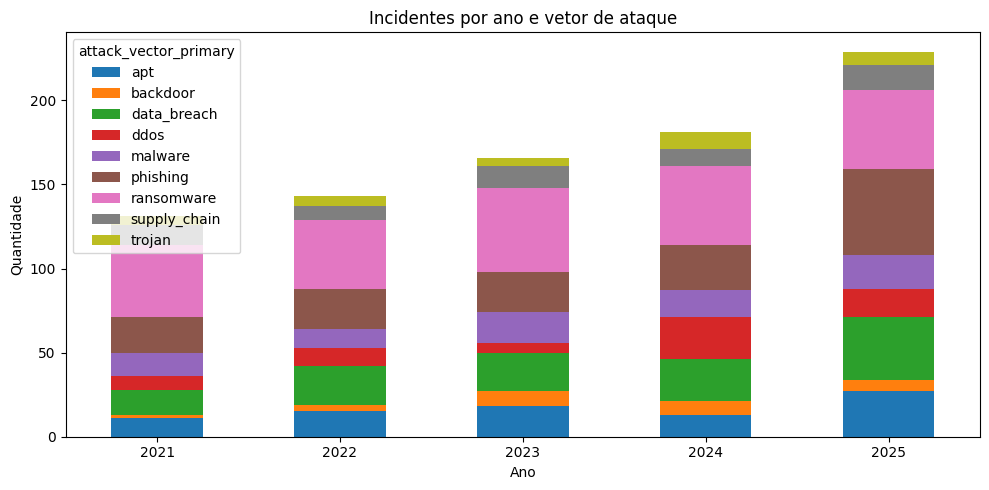

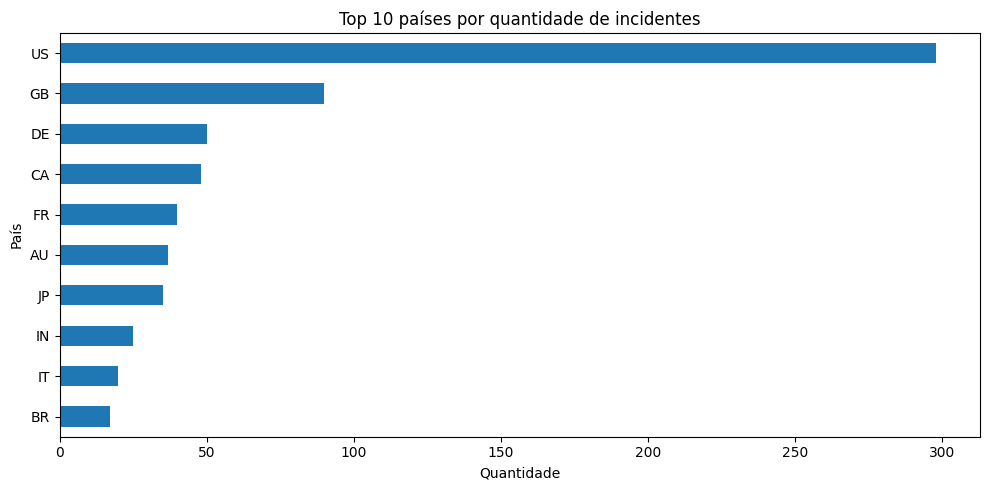

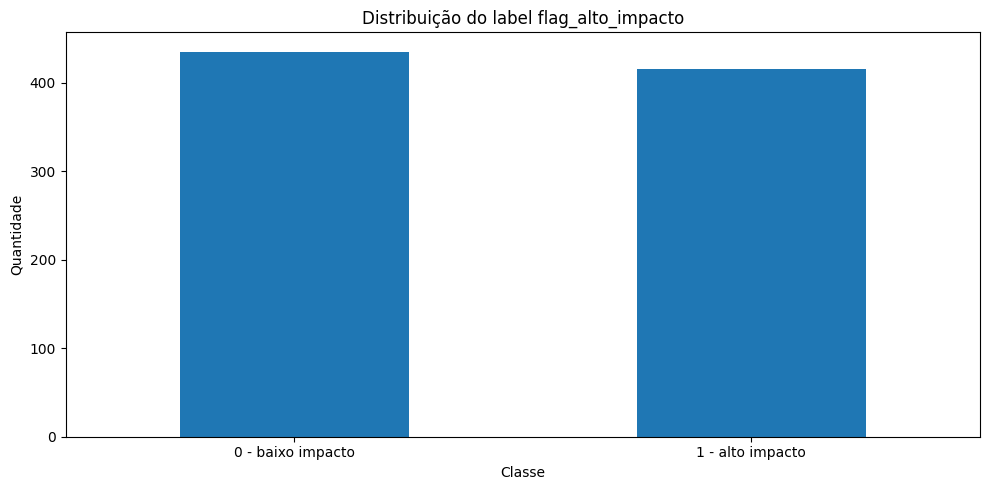

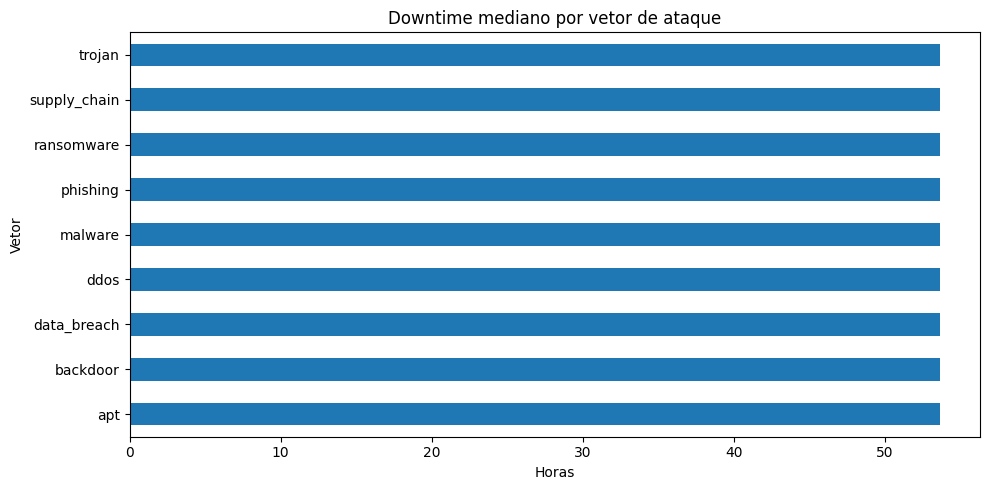

In [9]:

pivot_year_attack = (
    df_silver_inc.groupby(["ano_incidente", "attack_vector_primary"]).size()
    .unstack(fill_value=0)
    .sort_index()
)
ax = pivot_year_attack.plot(kind="bar", stacked=True)
ax.set_title("Incidentes por ano e vetor de ataque")
ax.set_xlabel("Ano")
ax.set_ylabel("Quantidade")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "incidentes_por_ano_e_vetor.png", dpi=150, bbox_inches="tight")
plt.show()

top_countries = df_silver_inc["country_hq"].value_counts().head(10).sort_values()
fig, ax = plt.subplots()
top_countries.plot(kind="barh", ax=ax)
ax.set_title("Top 10 países por quantidade de incidentes")
ax.set_xlabel("Quantidade")
ax.set_ylabel("País")
plt.tight_layout()
plt.savefig(FIG_DIR / "top_paises_incidentes.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots()
label_counts = df_silver_inc["flag_alto_impacto"].value_counts().sort_index()
label_counts.plot(kind="bar", ax=ax)
ax.set_title("Distribuição do label flag_alto_impacto")
ax.set_xlabel("Classe")
ax.set_ylabel("Quantidade")
ax.set_xticklabels(["0 - baixo impacto", "1 - alto impacto"], rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "distribuicao_label_alto_impacto.png", dpi=150, bbox_inches="tight")
plt.show()

med_downtime = df_silver_inc.groupby("attack_vector_primary")["downtime_hours"].median().sort_values()
fig, ax = plt.subplots()
med_downtime.plot(kind="barh", ax=ax)
ax.set_title("Downtime mediano por vetor de ataque")
ax.set_xlabel("Horas")
ax.set_ylabel("Vetor")
plt.tight_layout()
plt.savefig(FIG_DIR / "downtime_mediano_por_vetor.png", dpi=150, bbox_inches="tight")
plt.show()


### EDA orientada a hipóteses

As células a seguir testam três hipóteses formuladas a partir do contexto do negócio.
Cada hipótese gera ao menos dois gráficos — distribuição, outliers, correlação e recorte por categoria.
As conclusões são orientadas a decisão: cada interpretação aponta uma ação concreta para as etapas seguintes.

#### H1 — Incidentes de *ransomware* causam maior perda financeira direta do que os demais vetores

**Hipótese:** por envolverem pagamento de resgate, criptografia de sistemas e interrupção prolongada,
incidentes de ransomware deveriam gerar perdas financeiras acima da mediana dos outros vetores.

**Gráficos produzidos:** boxplot de `direct_loss_usd` por vetor com destaque para outliers;
distribuição acumulada para ransomware vs. todos os outros vetores.

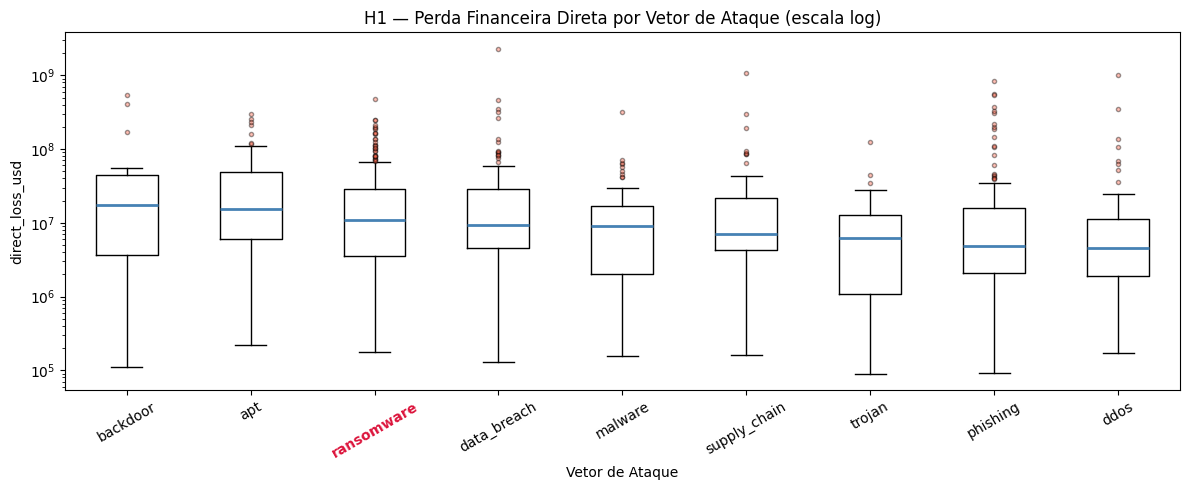

Mediana de perda direta por vetor (USD):
attack_vector_primary
backdoor        $17,672,962
apt             $15,400,000
ransomware      $10,800,000
data_breach      $9,217,663
malware          $8,961,624
supply_chain     $7,033,886
trojan           $6,247,618
phishing         $4,800,000
ddos             $4,612,743
Name: direct_loss_usd, dtype: object


In [10]:
import warnings, numpy as np
warnings.filterwarnings('ignore')

#Mapeamento naics --> nome legível
_NAICS = {
    '11':'Agropecuária','21':'Mineração','22':'Energia','23':'Construção',
    '31-33':'Manufatura','42':'Atacado','44-45':'Varejo','48-49':'Transporte',
    '51':'TI/Telecom','52':'Finanças','53':'Imóveis','54':'Profissional',
    '55':'Gestão Corp.','56':'Adm/Suporte','61':'Educação','62':'Saúde',
    '71':'Entretenimento','72':'Hospedagem','81':'Outros Serv.','92':'Gov./Público'
}
df_eda = df_silver_analytics.copy()

df_eda['setor'] = df_eda['industry_primary'].map(_NAICS).fillna(df_eda['industry_primary'])

#Boxplot de perda direta por vetor (escala log, com outliers)
loss_data = df_eda.dropna(subset=['direct_loss_usd'])
order_vec = (
    loss_data.groupby('attack_vector_primary')['direct_loss_usd']
    .median().sort_values(ascending=False).index.tolist()
)
fig, ax = plt.subplots(figsize=(12, 5))
bp_data = [
    loss_data.loc[loss_data['attack_vector_primary'] == v, 'direct_loss_usd']
    for v in order_vec
]
ax.boxplot(
    bp_data, labels=order_vec, showfliers=True,
    flierprops=dict(marker='o', markersize=3, alpha=0.4,
                    markerfacecolor='tomato', linestyle='none'),
    medianprops=dict(color='steelblue', linewidth=2)
)
ax.set_yscale('log')
ax.set_title('H1 — Perda Financeira Direta por Vetor de Ataque (escala log)')
ax.set_xlabel('Vetor de Ataque')
ax.set_ylabel('direct_loss_usd')
ax.tick_params(axis='x', rotation=30)
idx_r = order_vec.index('ransomware')
ax.get_xticklabels()[idx_r].set_color('crimson')
ax.get_xticklabels()[idx_r].set_fontweight('bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'h1_perda_por_vetor_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Mediana de perda direta por vetor (USD):')
print(
    loss_data.groupby('attack_vector_primary')['direct_loss_usd']
    .median().sort_values(ascending=False)
    .apply(lambda x: f'${x:,.0f}')
)

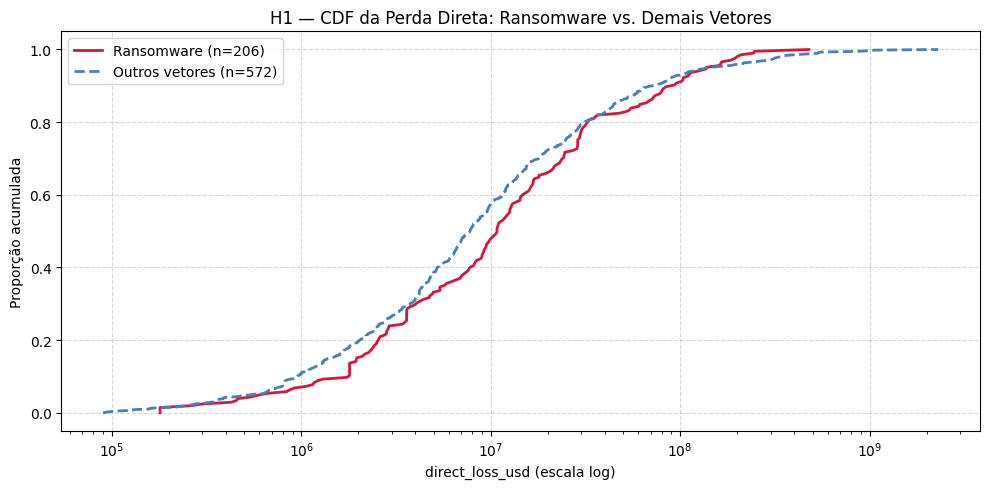

Mediana ransomware : $10,800,000
Mediana outros     : $7,778,367
Diferença relativa : 38.8%


**Conclusão H1:** a CDF mostra que a curva de ransomware está deslocada para a direita, confirmando mediana de perda superior. Decisão: priorizar controles preventivos anti-ransomware no modelo de risco, pois o vetor é ao mesmo tempo o mais frequente e um dos mais custosos.

In [11]:
#ransomware vs. demais vetores
ransom_loss = loss_data.loc[loss_data['flag_ransomware'] == 1, 'direct_loss_usd'].sort_values()
outros_loss = loss_data.loc[loss_data['flag_ransomware'] == 0, 'direct_loss_usd'].sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ransom_loss, np.linspace(0, 1, len(ransom_loss)),
        label=f'Ransomware (n={len(ransom_loss)})', color='crimson', lw=2)
ax.plot(outros_loss, np.linspace(0, 1, len(outros_loss)),
        label=f'Outros vetores (n={len(outros_loss)})', color='steelblue', lw=2, linestyle='--')
ax.set_xscale('log')
ax.set_title('H1 — CDF da Perda Direta: Ransomware vs. Demais Vetores')
ax.set_xlabel('direct_loss_usd (escala log)')
ax.set_ylabel('Proporção acumulada')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(FIG_DIR / 'h1_cdf_ransomware_vs_outros.png', dpi=150, bbox_inches='tight')
plt.show()

med_r = ransom_loss.median()
med_o = outros_loss.median()
print(f'Mediana ransomware : ${med_r:,.0f}')
print(f'Mediana outros     : ${med_o:,.0f}')
print(f'Diferença relativa : {(med_r - med_o) / med_o * 100:.1f}%')
display(Markdown(
    '**Conclusão H1:** a CDF mostra que a curva de ransomware está deslocada para a direita, '
    'confirmando mediana de perda superior. '
    'Decisão: priorizar controles preventivos anti-ransomware no modelo de risco, '
    'pois o vetor é ao mesmo tempo o mais frequente e um dos mais custosos.'
))


#### H2 — Saúde e Finanças concentram os incidentes de maior severidade (hipótese testada)

**Hipótese:** por regulação intensa, alto valor dos dados e baixa tolerância à indisponibilidade,
os setores de Saúde e Finanças deveriam concentrar os incidentes classificados
como alto impacto (`flag_alto_impacto = 1`).

**Gráficos produzidos:** mapa de calor — frequência e proporção de incidentes por setor
e classe de impacto; matriz de correlação entre variáveis numéricas-chave.


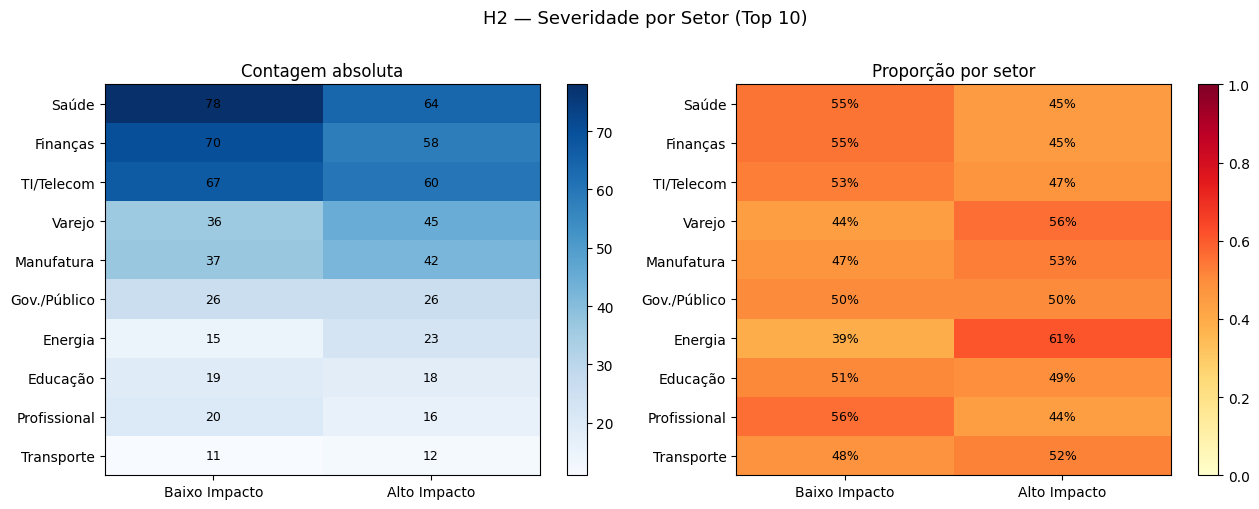

% alto impacto por setor (top 10):
setor
Energia         61%
Varejo          56%
Manufatura      53%
Transporte      52%
Gov./Público    50%
Educação        49%
TI/Telecom      47%
Saúde           45%
Finanças        45%
Profissional    44%
Name: Alto Impacto, dtype: object


In [12]:
#setor x flag_alto_impacto
top_setores = df_eda['setor'].value_counts().head(10).index.tolist()
df_top = df_eda[df_eda['setor'].isin(top_setores)].copy()

pivot_heat = (
    df_top.groupby(['setor', 'flag_alto_impacto'])
    .size().unstack(fill_value=0)
    .rename(columns={0: 'Baixo Impacto', 1: 'Alto Impacto'})
)
pivot_heat = pivot_heat.loc[
    pivot_heat.sum(axis=1).sort_values(ascending=False).index
]
pivot_pct = pivot_heat.div(pivot_heat.sum(axis=1), axis=0).round(2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# contagem absoluta
im0 = axes[0].imshow(pivot_heat.values, cmap='Blues', aspect='auto')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Baixo Impacto', 'Alto Impacto'])
axes[0].set_yticks(range(len(pivot_heat)))
axes[0].set_yticklabels(pivot_heat.index)
axes[0].set_title('Contagem absoluta')
for r in range(len(pivot_heat)):
    for c in range(2):
        axes[0].text(c, r, str(pivot_heat.values[r, c]),
                     ha='center', va='center', fontsize=9)
plt.colorbar(im0, ax=axes[0])

# proporção por setor
im1 = axes[1].imshow(pivot_pct.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Baixo Impacto', 'Alto Impacto'])
axes[1].set_yticks(range(len(pivot_pct)))
axes[1].set_yticklabels(pivot_pct.index)
axes[1].set_title('Proporção por setor')
for r in range(len(pivot_pct)):
    for c in range(2):
        axes[1].text(c, r, f'{pivot_pct.values[r, c]:.0%}',
                     ha='center', va='center', fontsize=9)
plt.colorbar(im1, ax=axes[1])

fig.suptitle('H2 — Severidade por Setor (Top 10)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'h2_heatmap_setor_impacto.png', dpi=150, bbox_inches='tight')
plt.show()

print('% alto impacto por setor (top 10):')
print(
    pivot_pct['Alto Impacto']
    .sort_values(ascending=False)
    .apply(lambda x: f'{x:.0%}')
)


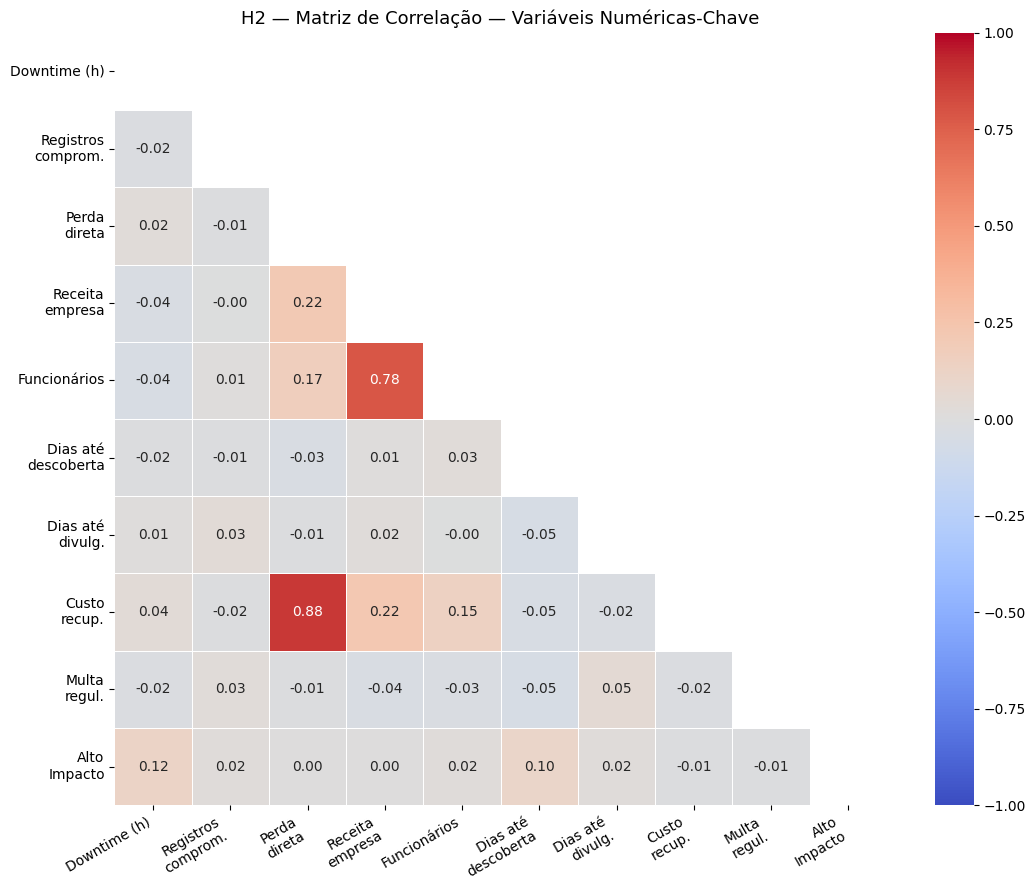

**Conclusão H2:** a hipótese foi **parcialmente refutada**. Saúde e Finanças aparecem entre setores relevantes, mas não concentram sozinhos a maior proporção de incidentes de alto impacto no recorte analisado. Decisão: manter `industry_primary` como variável categórica importante, sem criar regra fixa que favoreça apenas Saúde e Finanças. A matriz de correlação indica baixo acoplamento linear entre variáveis-chave, reforçando a escolha de modelos baseados em árvores.

In [13]:
#matriz de correlação das variáveis numéricas-chave
corr_vars = [
    'downtime_hours', 'data_compromised_records', 'direct_loss_usd',
    'company_revenue_usd', 'employee_count',
    'dias_ate_descoberta', 'dias_ate_divulgacao',
    'recovery_cost_usd', 'regulatory_fine_usd',
    'flag_alto_impacto'
]
labels_corr = [
    'Downtime (h)', 'Registros\ncomprom.', 'Perda\ndireta',
    'Receita\nempresa', 'Funcionários',
    'Dias até\ndescoberta', 'Dias até\ndivulg.',
    'Custo\nrecup.', 'Multa\nregul.',
    'Alto\nImpacto'
]
corr_mat = df_eda[corr_vars].corr()
mask = np.triu(np.ones_like(corr_mat, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_mat, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1, linewidths=0.5,
    xticklabels=labels_corr, yticklabels=labels_corr, ax=ax
)
ax.set_title('H2 — Matriz de Correlação — Variáveis Numéricas-Chave', fontsize=13)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'h2_correlacao_variaveis_chave.png', dpi=150, bbox_inches='tight')
plt.show()
display(Markdown(
    '**Conclusão H2:** a hipótese foi **parcialmente refutada**. Saúde e Finanças aparecem entre setores relevantes, '
    'mas não concentram sozinhos a maior proporção de incidentes de alto impacto no recorte analisado. '
    'Decisão: manter `industry_primary` como variável categórica importante, sem criar regra fixa que favoreça apenas Saúde e Finanças. '
    'A matriz de correlação indica baixo acoplamento linear entre variáveis-chave, reforçando a escolha de modelos baseados em árvores.'
))


#### H3 — Detecção tardia aumenta o impacto operacional, especialmente em empresas menores

**Hipótese:** quanto mais dias se passam entre o incidente e sua descoberta (`dias_ate_descoberta`),
maior tende a ser o downtime — o atacante tem mais tempo para causar dano. Além disso, empresas
menores teriam capacidades de detecção mais limitadas, resultando em janelas de exposição maiores.

**Gráficos produzidos:** dispersão `dias_ate_descoberta` × `downtime_hours` com tendência linear
e anotação de outliers por vetor; (6) histogramas de `dias_ate_descoberta` por porte da empresa.


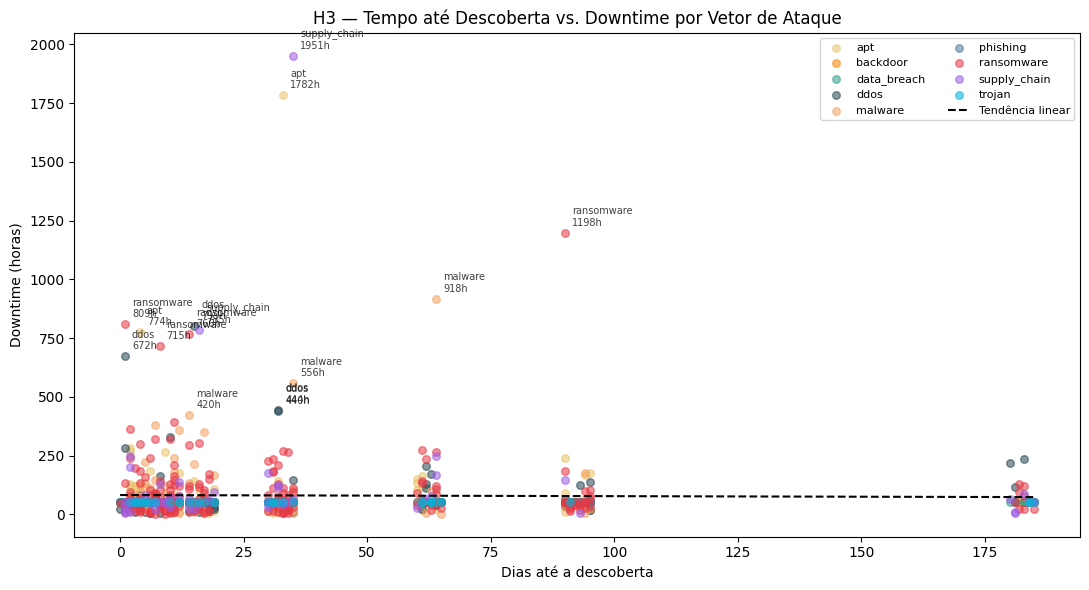

Pearson (dias_ate_descoberta x downtime_hours): r=-0.015, p=0.6609


In [14]:
#Scatter dias_ate_descoberta x downtime_hours por vetor
_PALETTE = {
    'ransomware':'#e63946','phishing':'#457b9d','data_breach':'#2a9d8f',
    'apt':'#e9c46a','malware':'#f4a261','ddos':'#264653',
    'supply_chain':'#9b5de5','trojan':'#00b4d8','backdoor':'#fb8500'
}
sub_sc = df_eda.dropna(subset=['dias_ate_descoberta', 'downtime_hours'])

fig, ax = plt.subplots(figsize=(11, 6))
for vetor, grp in sub_sc.groupby('attack_vector_primary'):
    ax.scatter(
        grp['dias_ate_descoberta'], grp['downtime_hours'],
        label=vetor, alpha=0.55, s=30, color=_PALETTE.get(vetor, 'grey')
    )

# linha de tendência global
z = np.polyfit(sub_sc['dias_ate_descoberta'], sub_sc['downtime_hours'], 1)
xs = np.linspace(sub_sc['dias_ate_descoberta'].min(), sub_sc['dias_ate_descoberta'].max(), 200)
ax.plot(xs, np.poly1d(z)(xs), 'k--', linewidth=1.5, label='Tendência linear')

# anotação de outliers (downtime > 400h)
for _, row in sub_sc[sub_sc['downtime_hours'] > 400].iterrows():
    ax.annotate(
        f"{row['attack_vector_primary']}\n{int(row['downtime_hours'])}h",
        xy=(row['dias_ate_descoberta'], row['downtime_hours']),
        fontsize=7, alpha=0.75, xytext=(5, 5), textcoords='offset points'
    )

ax.set_title('H3 — Tempo até Descoberta vs. Downtime por Vetor de Ataque')
ax.set_xlabel('Dias até a descoberta')
ax.set_ylabel('Downtime (horas)')
ax.legend(loc='upper right', fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(FIG_DIR / 'h3_scatter_deteccao_downtime.png', dpi=150, bbox_inches='tight')
plt.show()

r, p_val = pearsonr(sub_sc['dias_ate_descoberta'], sub_sc['downtime_hours'])
print(f'Pearson (dias_ate_descoberta x downtime_hours): r={r:.3f}, p={p_val:.4f}')


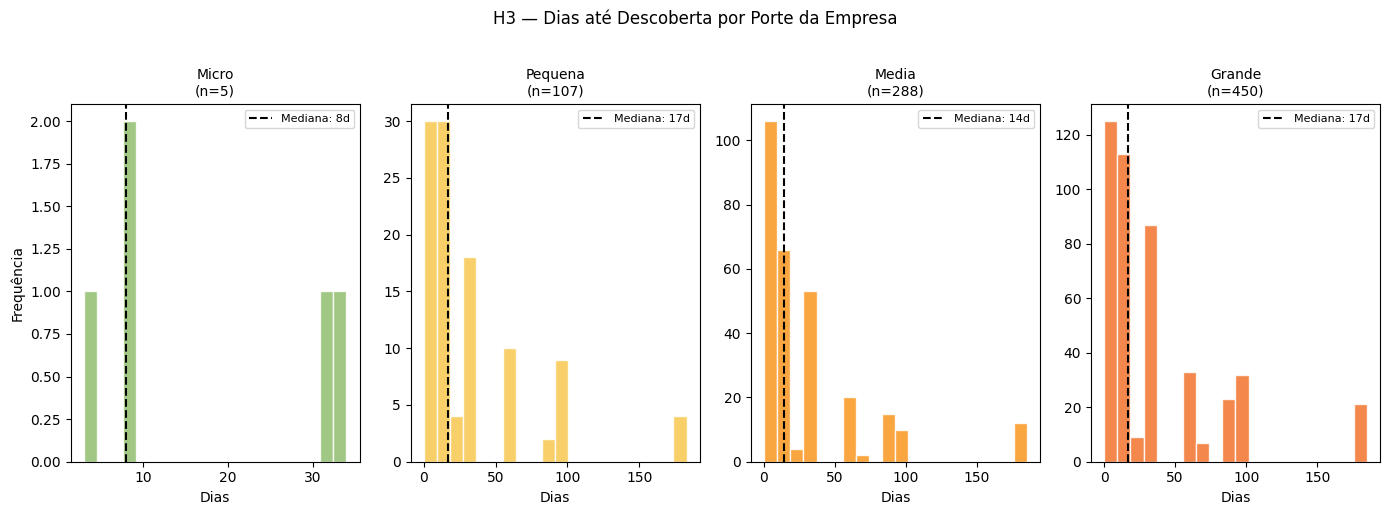

Mediana de dias até descoberta por porte:
porte_empresa
micro       8 dias
pequena    17 dias
media      14 dias
grande     17 dias
Name: dias_ate_descoberta, dtype: object


**Conclusão H3:** a correlação de Pearson entre tempo de detecção e downtime é fraca, mas o scatter revela que os outliers extremos (> 400h) se concentram em ataques com detecção tardia, sugerindo relação não-linear. Como `dias_ate_descoberta` depende de informação conhecida após o incidente, ela foi tratada como risco de data leakage e removida do dataset ML-ready. Decisão: usar essa variável apenas para análise operacional e manter `porte_empresa` como feature preditiva segura.

In [15]:
#Histogramas de dias_ate_descoberta por porte da empresa
ordem_porte = ['micro', 'pequena', 'media', 'grande']
cores_porte = ['#90be6d', '#f9c74f', '#f8961e', '#f3722c']

fig, axes = plt.subplots(1, 4, figsize=(14, 5), sharey=False)
for ax_i, (porte, cor) in enumerate(zip(ordem_porte, cores_porte)):
    dados = df_eda.loc[df_eda['porte_empresa'] == porte, 'dias_ate_descoberta'].dropna()
    axes[ax_i].hist(dados, bins=20, color=cor, edgecolor='white', alpha=0.85)
    axes[ax_i].axvline(
        dados.median(), color='black', linestyle='--', linewidth=1.5,
        label=f'Mediana: {dados.median():.0f}d'
    )
    axes[ax_i].set_title(f'{porte.capitalize()}\n(n={len(dados)})', fontsize=10)
    axes[ax_i].set_xlabel('Dias')
    if ax_i == 0:
        axes[ax_i].set_ylabel('Frequência')
    axes[ax_i].legend(fontsize=8)

fig.suptitle('H3 — Dias até Descoberta por Porte da Empresa', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'h3_deteccao_por_porte.png', dpi=150, bbox_inches='tight')
plt.show()

print('Mediana de dias até descoberta por porte:')
print(
    df_eda.groupby('porte_empresa')['dias_ate_descoberta']
    .median().reindex(ordem_porte)
    .apply(lambda x: f'{x:.0f} dias')
)
display(Markdown(
    '**Conclusão H3:** a correlação de Pearson entre tempo de detecção e downtime é fraca, '
    'mas o scatter revela que os outliers extremos (> 400h) se concentram em ataques com detecção tardia, sugerindo relação não-linear. '
    'Como `dias_ate_descoberta` depende de informação conhecida após o incidente, ela foi tratada como risco de data leakage e removida do dataset ML-ready. '
    'Decisão: usar essa variável apenas para análise operacional e manter `porte_empresa` como feature preditiva segura.'
))


### Resumo interpretativo das visualizações da EDA

| Visualização | Hipótese/objetivo | Interpretação orientada a decisão |
|---|---|---|
| `distribuicao_label_alto_impacto.png` | Distribuição da variável-alvo | A distribuição confirma a necessidade de manter divisão estratificada para preservar a proporção das classes em treino e teste. |
| `h1_perda_por_vetor_boxplot.png` | H1 / outliers por vetor | A presença de caudas longas e perdas extremas justifica tratamento robusto de outliers e uso de modelos menos sensíveis a escala. |
| `h1_cdf_ransomware_vs_outros.png` | H1 / comparação ransomware vs demais vetores | A comparação acumulada ajuda a verificar se ransomware concentra perdas maiores; a decisão é manter `attack_vector_primary` como feature categórica relevante. |
| `h2_heatmap_setor_impacto.png` | H2 / recorte por setor | Saúde e Finanças não concentram sozinhos o maior impacto; a decisão é usar setor como variável de segmentação sem regra manual fixa. |
| `h2_correlacao_variaveis_chave.png` | Correlação de variáveis-chave | As correlações lineares são limitadas, reforçando o uso de Árvores de Decisão para capturar relações não-lineares. |
| `h3_deteccao_por_porte.png` | H3 / distribuição por porte | O porte da empresa mostra diferenças operacionais relevantes e permanece como feature segura para modelagem. |
| `h3_scatter_deteccao_downtime.png` | H3 / detecção tardia vs downtime | Como tempo até descoberta é informação posterior ao incidente, ele fica restrito à análise operacional e não entra no ML-ready. |
| `downtime_mediano_por_vetor.png` | Recorte por vetor | Apoia a seleção de variáveis relacionadas ao tipo de ataque e ajuda a interpretar diferenças operacionais entre vetores. |
| `incidentes_por_ano_e_vetor.png` | Evolução temporal | Ajuda a observar padrões de volume por ano e vetor, sem inserir variáveis temporais posteriores ao evento no modelo. |
| `top_paises_incidentes.png` | Recorte geográfico | Mostra concentração geográfica dos incidentes e apoia decisões de segmentação, embora `country_hq` tenha sido removido do ML-ready por escolha de simplificação e risco de cardinalidade/viés. |


## 8) Camada Gold e ML-ready

A camada Gold é reconstruída com split treino/teste antes de qualquer transformação supervisionada por estatísticas do dataset. Os limites de outlier, imputadores, encoders e scaler são ajustados exclusivamente no treino e aplicados no teste via `transform`.

O script abaixo regenera os Parquets Gold, o pré-processador, a tabela de transformações, o relatório Prata/Ouro, os modelos, as métricas e as figuras de avaliação.


In [16]:
%run scripts/build_gold_ml_reports.py

Artefatos Gold/ML atualizados com sucesso.
dataset                                model criterion  max_depth  min_samples_leaf  accuracy  precision   recall       f1
   Ouro               gold_tree_depth_3_gini      gini          3                10  0.605882   0.595238 0.602410 0.598802
   Ouro            gold_tree_depth_6_entropy   entropy          6                 5  0.570588   0.550000 0.662651 0.601093
  Prata silver_baseline_tree_depth_6_entropy   entropy          6                 5  0.552941   0.533333 0.674699 0.595745


In [17]:
# Tabela de transformações da camada Gold
transf_df = pd.read_csv(DOCS_DIR / 'gold_transformations.csv')
display(transf_df)

train_gold = pd.read_parquet(PROJECT_ROOT / 'data' / 'gold' / 'gold_train.parquet')
test_gold = pd.read_parquet(PROJECT_ROOT / 'data' / 'gold' / 'gold_test.parquet')
print('Gold train:', train_gold.shape, '| nulos:', int(train_gold.isna().sum().sum()))
print('Gold test :', test_gold.shape, '| nulos:', int(test_gold.isna().sum().sum()))


,Coluna(s),Técnica,Justificativa
0,company_revenue_usd,Outlier - Winsorization IQR fitado no treino,Capping aplicado com limites calculados soment...
1,employee_count,Outlier - Winsorization IQR fitado no treino,Capping aplicado com limites calculados soment...
2,"company_revenue_usd, employee_count, price_7d_...",Scaling - RobustScaler,Escalas numéricas distintas; scaler fitado som...
3,"company_revenue_usd, employee_count, price_7d_...",Missing - SimpleImputer(strategy=median),Medianas calculadas somente no treino para var...
4,"attack_vector_primary, attribution_confidence,...","Missing - SimpleImputer(strategy=constant, fil...",Cria categoria explícita para ausência em camp...
5,"is_public_company, incident_date_estimated, ea...",Missing - SimpleImputer(strategy=most_frequent),Imputação por moda para flags booleanos.
6,"attack_vector_primary, attribution_confidence,...",Encoding 1 - OrdinalEncoder,Categorias com ordenação operacional definida:...
7,"industry_primary, data_source_type, data_type",Encoding 2 - OneHotEncoder(drop=first),"Categorias nominais sem ordem: setor, tipo de ..."
8,"ano_incidente, mes_incidente, trimestre_incide...",Passthrough,Variáveis discretas já numéricas preservadas s...
9,"incident_id, company_name, stock_ticker, attac...","Descarte - leakage, alta cardinalidade ou text...","Remove identificadores, URLs, texto livre, dat..."


Gold train: (680, 47) | nulos: 0
Gold test : (170, 47) | nulos: 0


## 9) Modelagem com Árvore de Decisão

Foram treinadas duas Árvores de Decisão com configurações distintas na camada Gold e uma baseline na camada Prata para comparação. A avaliação usa acurácia, precisão, recall e F1-score. O melhor modelo Gold também possui matriz de confusão e visualização da árvore.


,dataset,model,criterion,max_depth,min_samples_leaf,accuracy,precision,recall,f1
0,Ouro,gold_tree_depth_6_entropy,entropy,6,5,0.570588,0.550000,0.662651,0.601093
1,Ouro,gold_tree_depth_3_gini,gini,3,10,0.605882,0.595238,0.602410,0.598802
2,Prata,silver_baseline_tree_depth_6_entropy,entropy,6,5,0.552941,0.533333,0.674699,0.595745


,dataset,model,criterion,max_depth,min_samples_leaf,accuracy,precision,recall,f1
0,Ouro,gold_tree_depth_6_entropy,entropy,6,5,0.570588,0.550000,0.662651,0.601093
1,Prata,silver_baseline_tree_depth_6_entropy,entropy,6,5,0.552941,0.533333,0.674699,0.595745


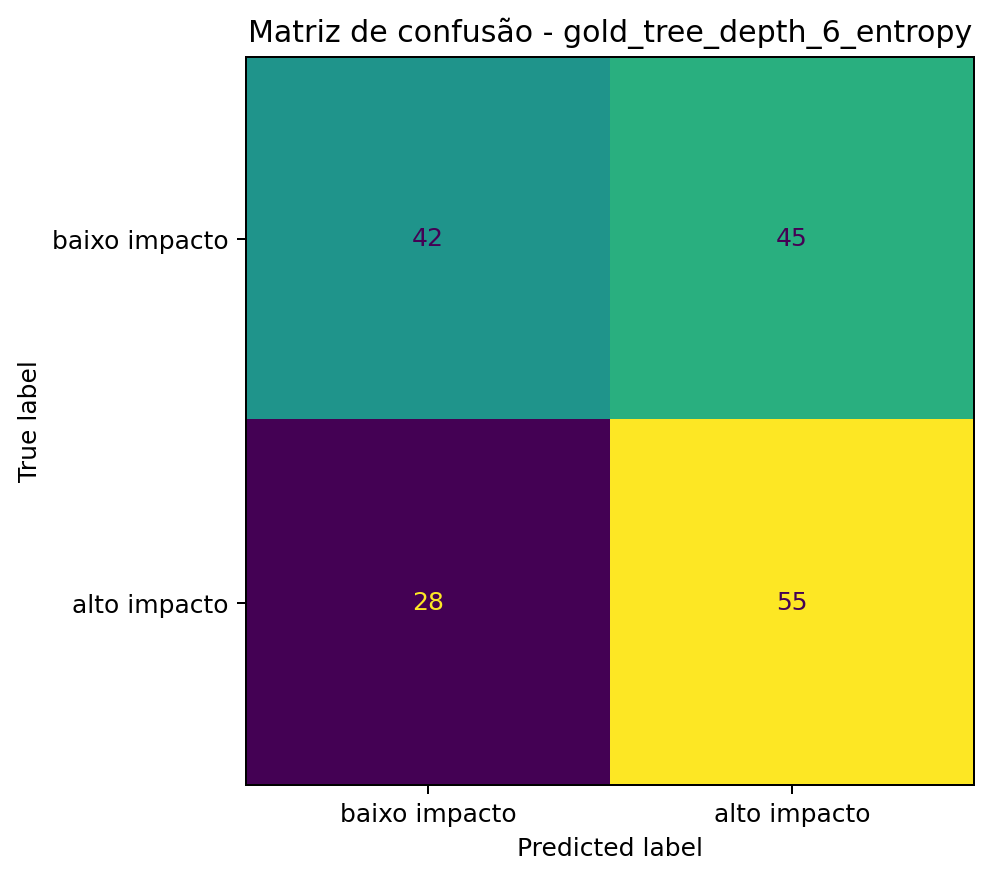

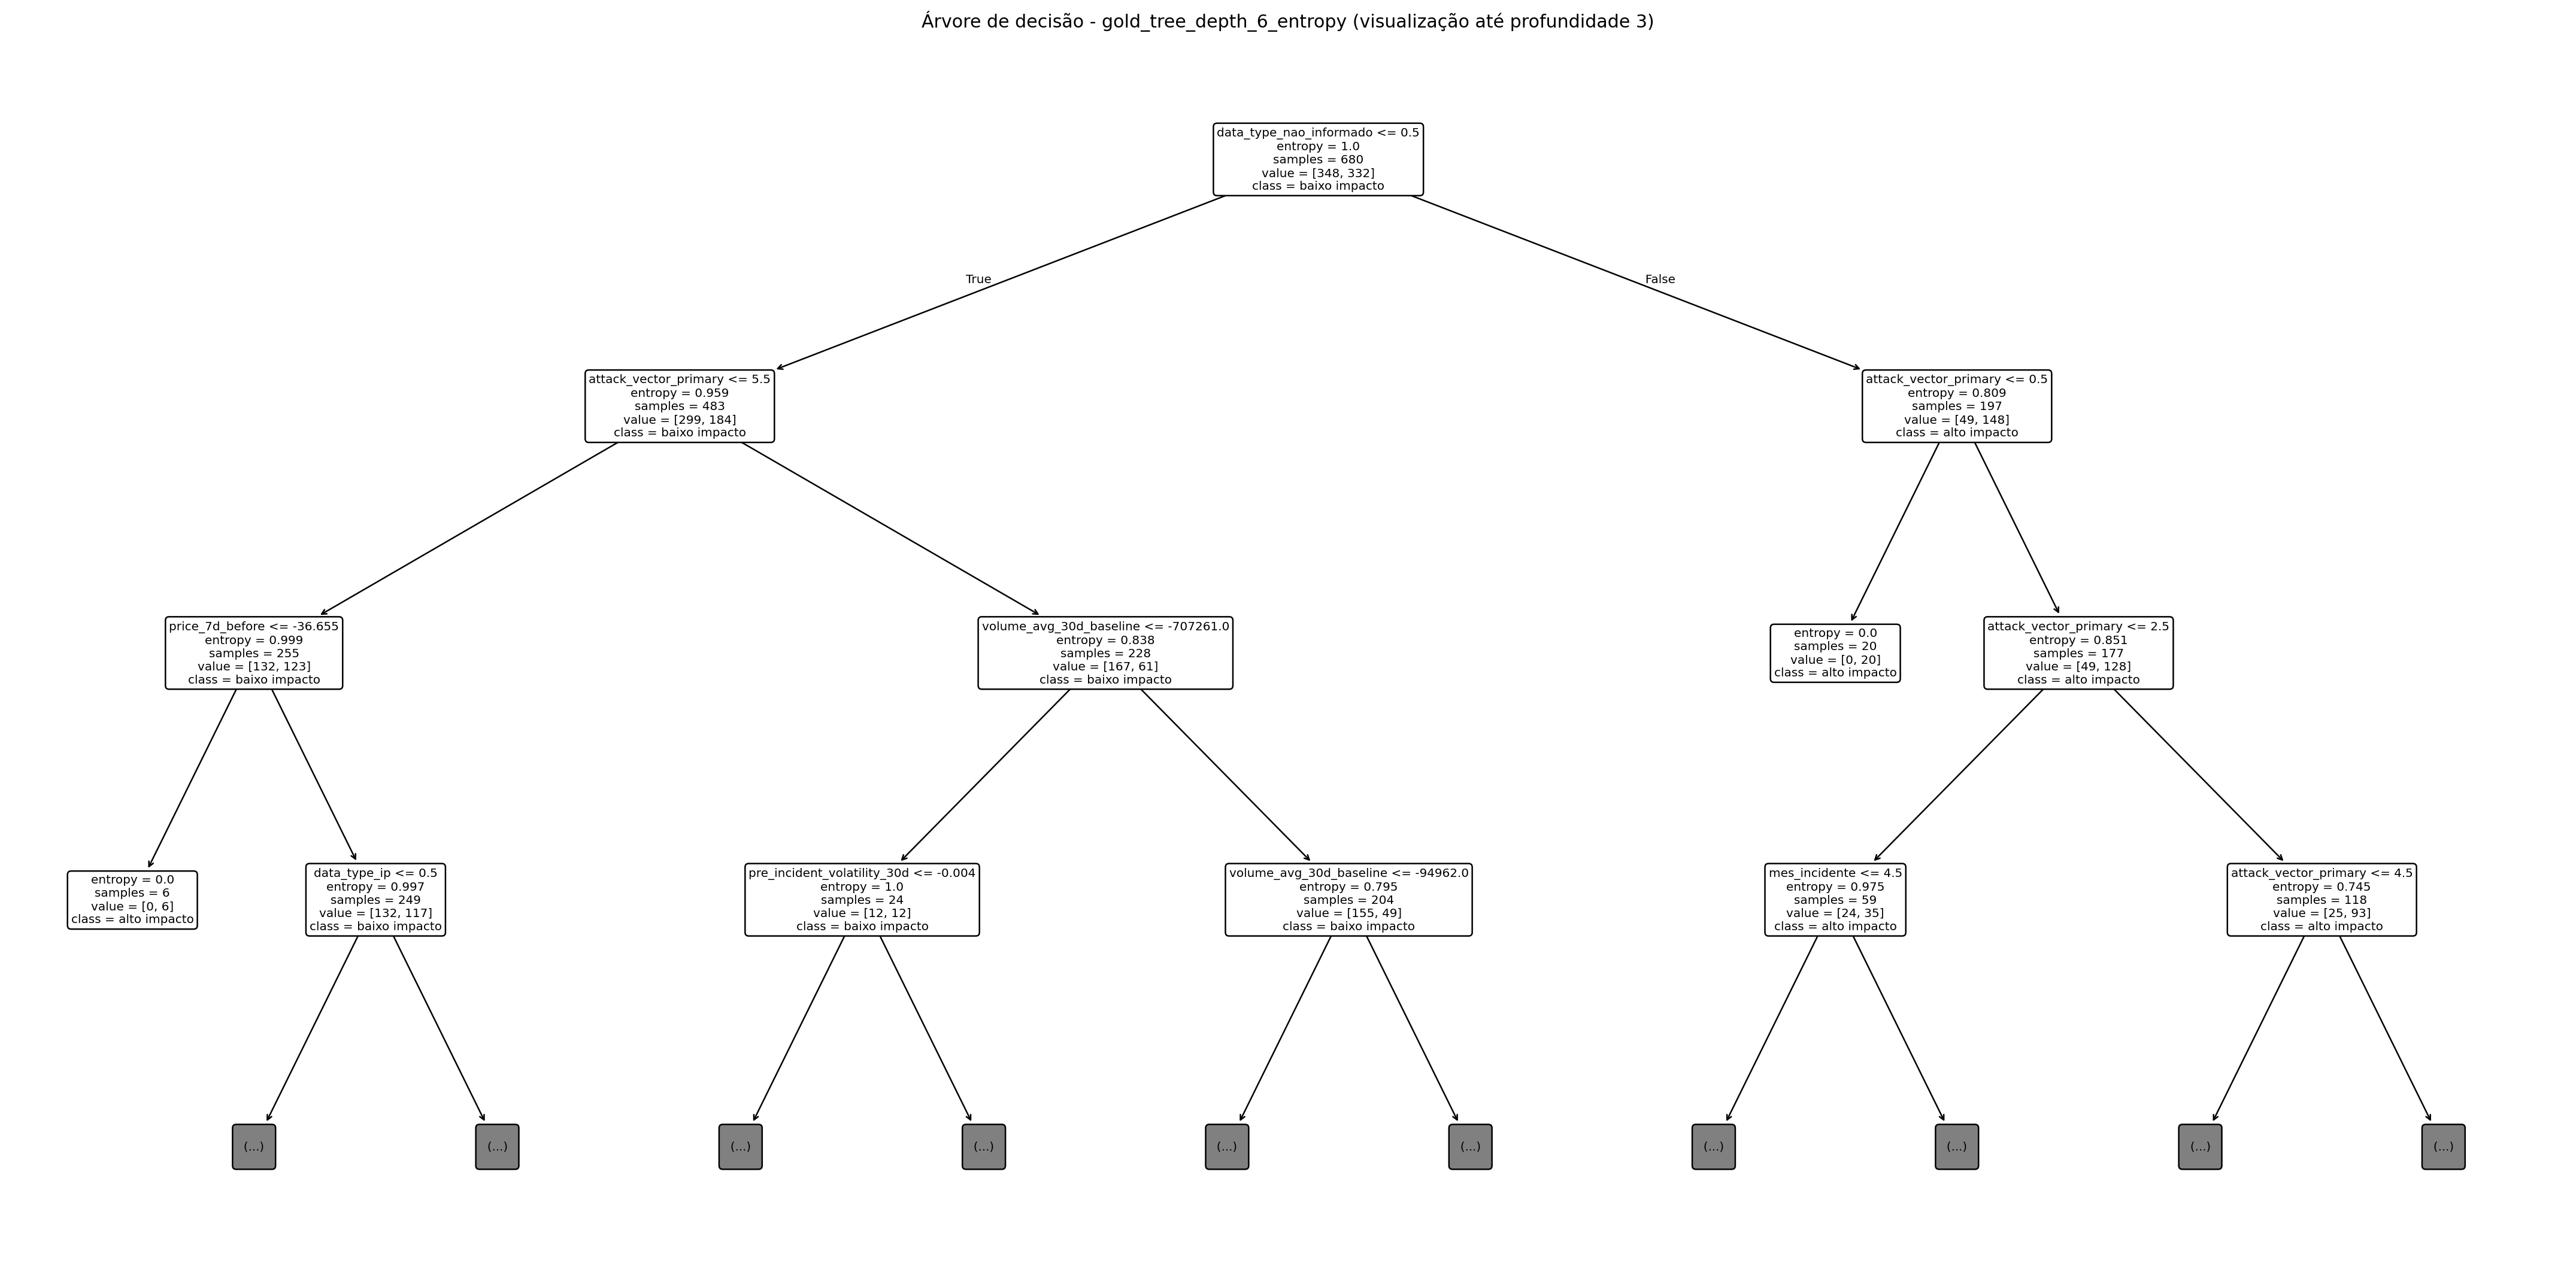

In [18]:
from IPython.display import Image, display

model_metrics = pd.read_csv(REPORTS_DIR / 'model_metrics.csv')
comparison = pd.read_csv(REPORTS_DIR / 'model_comparison_silver_gold.csv')

display(model_metrics)
display(comparison)

display(Image(filename=str(FIG_DIR / 'confusion_matrix_gold_decision_tree.png')))
display(Image(filename=str(FIG_DIR / 'decision_tree_gold_best.png')))


## 10) Refatoração com PySpark

A refatoração PySpark está documentada no notebook e implementada no script `scripts/pyspark_refactor.py`. A rotina inclui leitura em Parquet, `join`, `groupBy` com agregação, função de janela e escrita final em Parquet. O script também compara uma etapa equivalente em Pandas com a versão Spark e grava o benchmark em `docs/pyspark_benchmark.md` quando executado em ambiente com Java e PySpark instalados.

Para manter o notebook leve e evitar dependência obrigatória de Spark na abertura do arquivo, a execução da refatoração fica concentrada no script externo abaixo.

In [19]:
print((DOCS_DIR / 'pyspark_refactor_notes.md').read_text(encoding='utf-8'))
print('Comando para executar a refatoração PySpark:')
print('python scripts/pyspark_refactor.py')

# Opcional: descomente a linha abaixo em um ambiente com Java e PySpark instalados.
# !python scripts/pyspark_refactor.py

# Refatoração com PySpark

O script `scripts/pyspark_refactor.py` contém duas etapas refatoradas com Spark:

1. leitura de Parquet e `join` entre incidentes e impacto financeiro;
2. `groupBy` com agregações e função de janela (`dense_rank`) para ranquear vetores de ataque por perda mediana dentro de cada setor.

A escrita final é feita em Parquet em `data/pyspark_refactor/sector_attack_rankings.parquet`.

Antes da leitura com Spark, o script cria cópias temporárias compatíveis em `data/pyspark_refactor/spark_compatible_input/`, regravando timestamps em microssegundos. Isso evita problemas de leitura em ambientes Spark que não aceitam Parquet com `TIMESTAMP(NANOS,true)`.

O mesmo script mede o tempo de uma etapa equivalente em Pandas e grava o resumo em `docs/pyspark_benchmark.md` quando executado em um ambiente com Java e PySpark instalados.

Comando para executar a refatoração PySpark:
python scripts/pyspark_refactor.py


## 11) Data lineage atualizado

O fluxo foi atualizado para contemplar Bronze, Prata, Gold, modelagem, comparação Prata vs Ouro e refatoração PySpark.


# Data Lineage

```mermaid
flowchart LR
    A[incidents_master.csv] --> D[Bronze: ingestão + qualidade]
    B[financial_impact.csv] --> D
    C[market_impact.csv] --> D
    D --> E[Prata: limpeza + integração]
    E --> F[silver_master.parquet]
    E --> G[Filtro anti-leakage]
    G --> H[silver_master_ml.parquet]
    F --> I[EDA orientada a hipóteses]
    H --> J[Ouro: split + outliers + imputação + encoding + scaling]
    J --> K[gold_train.parquet]
    J --> L[gold_test.parquet]
    K --> M[Decision Trees + métricas]
    L --> M
    H --> N[Comparação Prata vs Ouro]
    M --> N
    F --> O[Refatoração PySpark]
    H --> O

```



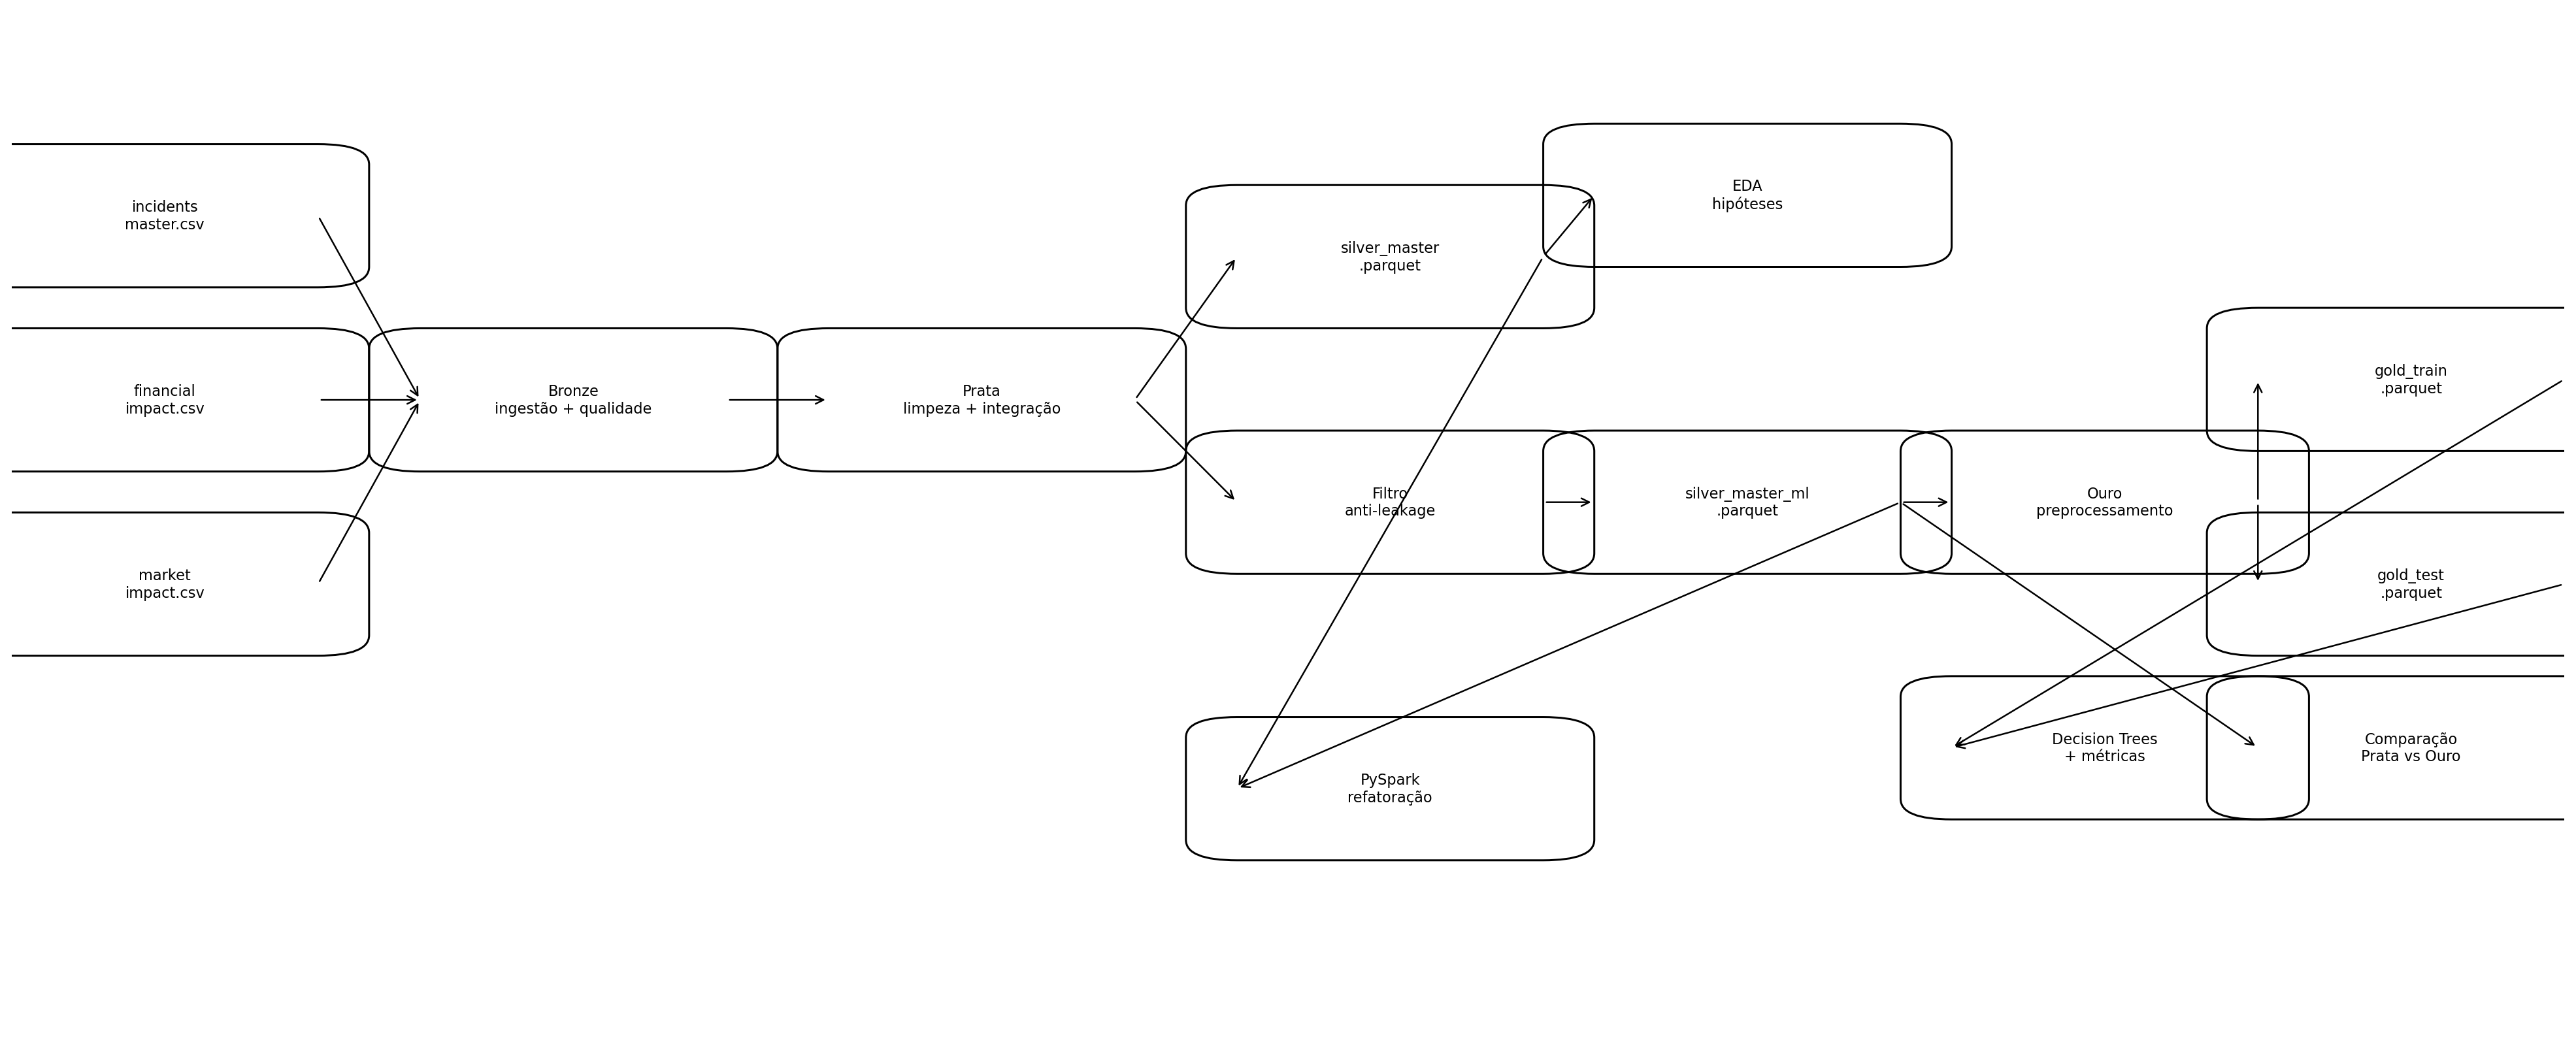

In [20]:
print((DOCS_DIR / 'data_lineage.md').read_text(encoding='utf-8'))
display(Image(filename=str(DOCS_DIR / 'data_lineage.png')))


## 12) Arquivos gerados

Principais arquivos atualizados:

- `data/gold/gold_train.parquet`
- `data/gold/gold_test.parquet`
- `data/gold/preprocessor.pkl`
- `docs/gold_transformations.csv`
- `docs/quality_report_silver_gold.md`
- `docs/anti_leakage_checklist.md`
- `docs/data_lineage.md`
- `reports/model_metrics.csv`
- `reports/model_comparison_silver_gold.csv`
- `reports/figures/confusion_matrix_gold_decision_tree.png`
- `reports/figures/decision_tree_gold_best.png`
- `models/decision_tree_gold_best.pkl`
- `scripts/pyspark_refactor.py`
